# BT4012 Kaggle Group 10: Health Insurance Fraud Detection
**Author:** (e1122416), Quek Ying Han Clare (e1156061), Eunice Gong Shi Min (e1155847)  
**Course:** BT4012  
**Institution:** National University of Singapore  
**Date:** November 2025

## Project Overview

This notebook presents a comprehensive approach to healthcare provider fraud detection using machine learning techniques. The goal is to classify healthcare providers as either fraudulent or non-fraudulent based on claims, beneficiary, and provider data.

**Dataset Context:**
- **Training data**: Historical claims, provider information, and beneficiary details with fraud labels  
- **Test data**: Unlabeled provider or claim records requiring fraud prediction  
- **Target variable**: Binary (0 = Non-Fraudulent, 1 = Fraudulent)  
- **Evaluation metric**: ROC AUC (Area Under the Curve), Precision, Recall, and F1-Score  

**Key Features:**
- Provider demographic and specialty information  
- Claims data (inpatient/outpatient claims, claim amounts, procedure codes)  
- Beneficiary information (age, gender, chronic conditions, number of visits)  
- Aggregated statistics per provider (average claim amount, claim frequency, diagnosis/procedure diversity)  

**Project Goals:**
1. Perform exploratory data analysis (EDA) to understand patterns and detect anomalies in claims and provider behavior.  
2. Engineer meaningful features to capture provider behavior trends and risk factors.  
3. Train and evaluate supervised machine learning models (e.g., Logistic Regression, Random Forest, XGBoost) to predict provider fraud.  
4. Implement interpretability techniques (e.g., SHAP values) to identify key features driving fraud predictions.  
5. Explore anomaly detection and unsupervised approaches to detect potential fraud not labeled in the dataset.  
6. Provide actionable insights for healthcare providers and insurers to mitigate fraudulent activities.

## Computational Dependencies & Dependencies

In [8]:
# Data manipulation
import numpy as np
import pandas as pd

# Machine learning models and preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Utilities
from tqdm import tqdm
import joblib
from pathlib import Path


## Load datasets
### Taken from Kaggle
**A) Inpatient Data**

This data provides insights about the claims filed for those patients who are admitted in the hospitals. It also provides additional details like their admission and discharge dates and admit d diagnosis code.

**B) Outpatient Data**

This data provides details about the claims filed for those patients who visit hospitals and not admitted in it.

**C) Beneficiary Details Data**

This data contains beneficiary KYC details like health conditions,regioregion they belong to etc.

In [8]:
data_dir = Path("data")

train_bene_path = data_dir / "Train_Beneficiarydata-1542865627584.csv"
train_inp_path  = data_dir / "Train_Inpatientdata-1542865627584.csv"
train_out_path  = data_dir / "Train_Outpatientdata-1542865627584.csv"
train_lbl_path  = data_dir / "Train-1542865627584.csv"

test_bene_path  = data_dir / "Test_Beneficiarydata-1542969243754.csv"
test_inp_path   = data_dir / "Test_Inpatientdata-1542969243754.csv"
test_out_path   = data_dir / "Test_Outpatientdata-1542969243754.csv"
test_lbl_path   = data_dir / "Test-1542969243754.csv"

train_beneficiary = pd.read_csv(train_bene_path)
train_inpatient = pd.read_csv(train_inp_path)
train_outpatient = pd.read_csv(train_out_path)
train_labels = pd.read_csv(train_lbl_path)

test_beneficiary = pd.read_csv(test_bene_path)
test_inpatient = pd.read_csv(test_inp_path)
test_outpatient = pd.read_csv(test_out_path)
test_labels = pd.read_csv(test_lbl_path)

## Data Cleaning

Cleaned data into 2 final datasets -> `train_merged` and `test_merged`


### Imports and Helpers

In [5]:
import pandas as pd
import numpy as np
from pathlib import Path

# --- general cleaning helpers ---
def normalize_columns(df):
    df = df.copy()
    df.columns = (
        df.columns.str.strip()
        .str.replace(r"\s+", "_", regex=True)
        .str.replace(r"[^\w_]", "", regex=True)
        .str.lower()
    )
    return df

def parse_dates_in_df(df):
    """Convert any column with 'date', 'dt', 'dob', 'dod', etc. to datetime."""
    df = df.copy()
    date_like = ["dt", "date", "dob", "dod", "claimstart", "claimend", "admission", "discharge"]
    for col in df.columns:
        if any(k in col for k in date_like):
            # Modern pandas: infer format automatically (no need for infer_datetime_format)
            df[col] = pd.to_datetime(df[col], errors="coerce")
    return df


def strip_strings(df):
    df = df.copy()
    for c in df.select_dtypes(include="object"):
        df[c] = df[c].astype(str).str.strip().replace({"": np.nan, "nan": np.nan, "NaN": np.nan})
    return df

def coerce_numeric(df):
    df = df.copy()
    for c in df.columns:
        if df[c].dtype == "object":
            s = df[c].dropna().astype(str).head(100)
            if len(s) and (s.str.match(r"^-?\d+(\.\d+)?$").mean() > 0.7):
                df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

def deduplicate(df, key_cols=None):
    df = df.copy()
    before = len(df)
    if key_cols:
        df = df.drop_duplicates(subset=key_cols, keep="first")
    else:
        df = df.drop_duplicates(keep="first")
    print(f"Removed {before-len(df)} duplicates")
    return df


### Clean Individual Files

How we cleaned:
- `normalize_columns(df)` -> Standardise column names for consistency and easy reference
    - Removes leading/training spaces in column names
    - Replaces spaces with underscores ('Claim Start Date' -> 'claim_start_date')
    - Removes special characters (like /, -, (, ))
    - Converts everything to lowercase
- `parse_dates_in_df(df)` -> Detect and convert all date-like columns into proper datetime objects
    - Looks for the respective columns and uses pd.to_datetime, to convert them
- `strip_strings(df)` -> Clean up messy text columns
    - Trims extra spaces from the start/end of strings
    - Converts empty strings ot text versions of NaN into real missy values
- `coerce_numeric(df)` -> Find columns that look numeric but are stored as strings, and convert them
    - Sees if most values match a numeric regex
    - If more than 70% look numeric, convert the whole column to float or int
-  `deduplicate(df)` -> Remove duplicate rows

In [10]:
def clean_dataframe(df, key_cols=None):
    print(f"\n--- Cleaning {df} ---")
    df = normalize_columns(df)
    df = strip_strings(df)
    df = parse_dates_in_df(df)
    df = coerce_numeric(df)
    df = deduplicate(df, key_cols)
    print(df.shape)
    return df

train_bene = clean_dataframe(train_beneficiary, ["beneid"])
train_inp  = clean_dataframe(train_inpatient, ["claimid"])
train_out  = clean_dataframe(train_outpatient, ["claimid"])
train_lbl  = clean_dataframe(train_labels)

test_bene  = clean_dataframe(test_beneficiary, ["beneid"])
test_inp   = clean_dataframe(test_inpatient, ["claimid"])
test_out   = clean_dataframe(test_outpatient, ["claimid"])
test_lbl   = clean_dataframe(test_labels)



--- Cleaning             BeneID         DOB  DOD  Gender  Race RenalDiseaseIndicator  \
0        BENE11001  1943-01-01  NaN       1     1                     0   
1        BENE11002  1936-09-01  NaN       2     1                     0   
2        BENE11003  1936-08-01  NaN       1     1                     0   
3        BENE11004  1922-07-01  NaN       1     1                     0   
4        BENE11005  1935-09-01  NaN       1     1                     0   
...            ...         ...  ...     ...   ...                   ...   
138551  BENE159194  1939-07-01  NaN       1     1                     0   
138552  BENE159195  1938-12-01  NaN       2     1                     0   
138553  BENE159196  1916-06-01  NaN       2     1                     0   
138554  BENE159197  1930-01-01  NaN       1     1                     0   
138555  BENE159198  1952-04-01  NaN       2     1                     0   

        State  County  NoOfMonths_PartACov  NoOfMonths_PartBCov  ...  \
0          39

### Merge train/test claims with beneficiaries

In [22]:
import pandas as pd

def _normalize_cols(df):
    """Lowercase & strip all column names for consistent joins."""
    df = df.copy()
    df.columns = df.columns.str.strip().str.lower()
    return df

def _clean_key(s):
    """Make join keys consistent (string, trimmed)."""
    return s.astype(str).str.strip()

def safe_merge(left, right, on, how="left", validate=None):
    """Wrapper to merge with safe suffix and optional validation."""
    return left.merge(
        right,
        on=on,
        how=how,
        suffixes=("", "_r"),
        validate=validate
    )

def merge_claims(inp, out, bene, prov_labels=None):
    """
    Create a unified claims dataframe:
      - concat inpatient & outpatient rows
      - left-join beneficiary on 'beneid'
      - (optional) left-join provider labels on 'provider' (many claims -> one label)

    Expected keys (lowercase): 'claimid', 'beneid', 'provider'
    """
    # --- normalize columns ---
    inp  = _normalize_cols(inp)
    out  = _normalize_cols(out)
    bene = _normalize_cols(bene)
    if prov_labels is not None:
        prov_labels = _normalize_cols(prov_labels)

    # --- build claims: union of columns, row-wise concat ---
    claims = pd.concat([inp, out], ignore_index=True, sort=False)

    # --- clean join keys present ---
    for key in ['claimid', 'beneid', 'provider']:
        if key in claims.columns:
            claims[key] = _clean_key(claims[key])
        if key in bene.columns:
            bene[key] = _clean_key(bene[key])
        if prov_labels is not None and key in getattr(prov_labels, 'columns', []):
            prov_labels[key] = _clean_key(prov_labels[key])

    # --- join beneficiary ---
    if 'beneid' in claims.columns and 'beneid' in bene.columns:
        claims = safe_merge(claims, bene, on=['beneid'], how='left', validate='many_to_one')

    # --- join provider labels (train only) ---
    if prov_labels is not None:
        # keep only provider + label, drop dups (one label per provider)
        label_cols = ['provider', 'potentialfraud']
        missing = [c for c in label_cols if c not in prov_labels.columns]
        if missing:
            raise ValueError(f"prov_labels is missing required columns: {missing}")

        prov_lab = (
            prov_labels[label_cols]
            .drop_duplicates(subset=['provider'])
        )
        claims = safe_merge(
            claims, prov_lab,
            on=['provider'],
            how='left',
            validate='many_to_one'  # many claims map to one provider label
        )

    return claims

# === Use it correctly ===
# Train gets labels; Test does NOT.
train_merged = merge_claims(train_inp, train_out, train_bene, prov_labels=train_lbl)
test_merged  = merge_claims(test_inp,  test_out,  test_bene,  prov_labels=None)

print("train_merged shape:", train_merged.shape)
print("test_merged  shape:", test_merged.shape)

# Quick sanity: do we have labels only in train?
print("PotentialFraud in train_merged?", 'potentialfraud' in train_merged.columns)
if 'potentialfraud' in train_merged.columns:
    print(train_merged['potentialfraud'].value_counts(dropna=False))

print("PotentialFraud in test_merged?", 'potentialfraud' in test_merged.columns)

print(train_merged.columns.tolist())


train_merged shape: (558211, 55)
test_merged  shape: (135392, 54)
PotentialFraud in train_merged? True
potentialfraud
No     345415
Yes    212796
Name: count, dtype: int64
PotentialFraud in test_merged? False
['beneid', 'claimid', 'claimstartdt', 'claimenddt', 'provider', 'inscclaimamtreimbursed', 'attendingphysician', 'operatingphysician', 'otherphysician', 'admissiondt', 'clmadmitdiagnosiscode', 'deductibleamtpaid', 'dischargedt', 'diagnosisgroupcode', 'clmdiagnosiscode_1', 'clmdiagnosiscode_2', 'clmdiagnosiscode_3', 'clmdiagnosiscode_4', 'clmdiagnosiscode_5', 'clmdiagnosiscode_6', 'clmdiagnosiscode_7', 'clmdiagnosiscode_8', 'clmdiagnosiscode_9', 'clmdiagnosiscode_10', 'clmprocedurecode_1', 'clmprocedurecode_2', 'clmprocedurecode_3', 'clmprocedurecode_4', 'clmprocedurecode_5', 'clmprocedurecode_6', 'dob', 'dod', 'gender', 'race', 'renaldiseaseindicator', 'state', 'county', 'noofmonths_partacov', 'noofmonths_partbcov', 'chroniccond_alzheimer', 'chroniccond_heartfailure', 'chroniccond_

## EDA

### Set up and helpers

In [11]:
# EDA helpers: no extra installs; uses pandas + matplotlib only
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

def pct_missing(s: pd.Series) -> float:
    return 100.0 * s.isna().mean()

def top_missing(df: pd.DataFrame, k: int = 20) -> pd.DataFrame:
    miss = df.isna().mean().sort_values(ascending=False)*100
    return miss.round(2).head(k).rename("missing_%").to_frame()

def date_ranges(df: pd.DataFrame) -> pd.DataFrame:
    # scan for datetime64 cols and return min/max
    dates = [c for c in df.columns if np.issubdtype(df[c].dtype, np.datetime64)]
    rows = []
    for c in dates:
        rows.append({
            "column": c,
            "min": df[c].min(),
            "max": df[c].max(),
            "missing_%": round(pct_missing(df[c]), 2),
        })
    return pd.DataFrame(rows).sort_values("column") if rows else pd.DataFrame(columns=["column","min","max","missing_%"])

def dtype_summary(df: pd.DataFrame) -> pd.DataFrame:
    dtypes = df.dtypes.astype(str).value_counts().rename("count").to_frame()
    dtypes["pct"] = (100 * dtypes["count"] / dtypes["count"].sum()).round(1)
    return dtypes

def categorical_columns(df: pd.DataFrame, max_unique: int = 30) -> list:
    cats = []
    for c in df.columns:
        if df[c].dtype == "object" or (df[c].dtype.name.startswith("category")):
            cats.append(c)
        else:
            # treat low-cardinality numerics as categorical too
            nun = df[c].nunique(dropna=True)
            if pd.api.types.is_integer_dtype(df[c]) and nun <= max_unique:
                cats.append(c)
    return cats

def numeric_columns(df: pd.DataFrame) -> list:
    return [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]

def eda_report(df: pd.DataFrame, name: str, sample_hist: int = 12):
    print(f"\n====================  {name}  ====================")
    print(f"shape: {df.shape[0]:,} rows x {df.shape[1]:,} cols")
    print("duplicate rows:", df.duplicated().sum())

    # dtypes overview
    print("\n-- dtypes summary --")
    display(dtype_summary(df))

    # missingness
    print("\n-- top missing columns --")
    display(top_missing(df, k=20))

    # date ranges
    dr = date_ranges(df)
    if len(dr):
        print("\n-- date ranges --")
        display(dr)

    # basic describe
    num_cols = numeric_columns(df)
    if num_cols:
        print("\n-- numeric summary (describe) --")
        display(df[num_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T)

    cat_cols = categorical_columns(df)
    if cat_cols:
        print("\n-- top categories (first 10 columns) --")
        for c in cat_cols[:10]:
            vc = df[c].value_counts(dropna=False).head(10)
            print(f"\n[{c}] top values:")
            display(vc)

    # correlation (quick)
    if len(num_cols) >= 2:
        print("\n-- numeric correlation (Pearson) --")
        corr = df[num_cols].corr(numeric_only=True)
        display(corr)

        # small heatmap for top-k numeric cols by variance
        topk = df[num_cols].var().sort_values(ascending=False).head(min(15, len(num_cols))).index
        plt.figure(figsize=(6, 5))
        plt.imshow(df[topk].corr(), interpolation="nearest")
        plt.title(f"{name}: correlation heatmap (top-var numerics)")
        plt.xticks(range(len(topk)), topk, rotation=90)
        plt.yticks(range(len(topk)), topk)
        plt.colorbar()
        plt.tight_layout()
        plt.show()

def target_report(df: pd.DataFrame, target_col: str = "potentialfraud"):
    if target_col in df.columns:
        print(f"\n-- target distribution: {target_col} --")
        vc = df[target_col].value_counts(dropna=False)
        pct = (vc / vc.sum() * 100).round(2)
        display(pd.DataFrame({"count": vc, "pct": pct}))
        plt.figure()
        vc.plot(kind="bar")
        plt.title(f"{target_col} distribution")
        plt.tight_layout()
        plt.show()
    else:
        print(f"(target '{target_col}' not found in dataframe)")


### Run on the cleaned tables


====================  train_beneficiary  ====================
shape: 138,556 rows x 25 cols
duplicate rows: 0

-- dtypes summary --


,count,pct
int64,21,84.0
datetime64[ns],2,8.0
object,1,4.0
float64,1,4.0



-- top missing columns --


,missing_%
dod,98.97
renaldiseaseindicator,14.13
beneid,0.00
chroniccond_obstrpulmonary,0.00
opannualreimbursementamt,0.00
ipannualdeductibleamt,0.00
ipannualreimbursementamt,0.00
chroniccond_stroke,0.00
chroniccond_rheumatoidarthritis,0.00
chroniccond_osteoporasis,0.00



-- date ranges --


...

chroniccond_cancer
2    121935
1     16621
Name: count, dtype: int64


[chroniccond_obstrpulmonary] top values:


chroniccond_obstrpulmonary
2    105697
1     32859
Name: count, dtype: int64


-- numeric correlation (Pearson) --


,gender,race,renaldiseaseindicator,state,county,noofmonths_partacov,noofmonths_partbcov,chroniccond_alzheimer,chroniccond_heartfailure,chroniccond_kidneydisease,chroniccond_cancer,chroniccond_obstrpulmonary,chroniccond_depression,chroniccond_diabetes,chroniccond_ischemicheart,chroniccond_osteoporasis,chroniccond_rheumatoidarthritis,chroniccond_stroke,ipannualreimbursementamt,ipannualdeductibleamt,opannualreimbursementamt,opannualdeductibleamt
gender,1.000000,0.002007,NaN,0.006893,0.004328,0.010458,0.010227,-0.017997,-0.008754,-0.005936,0.013080,-0.011717,-0.021261,-0.021193,-0.005754,-0.018978,-0.013450,-0.002649,0.001782,-0.000235,0.007061,0.007625
race,0.002007,1.000000,NaN,-0.049890,-0.003733,-0.005861,-0.002314,-0.000040,0.004511,-0.000500,0.013700,0.004945,-0.007103,0.002240,0.012074,0.007452,0.003813,0.003988,-0.003996,-0.004254,0.004534,0.001040
renaldiseaseindicator,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,0.006893,-0.049890,NaN,1.000000,0.130760,-0.001929,0.002039,0.000013,-0.001845,-0.001041,0.005807,-0.001066,-0.001205,0.001263,-0.000245,0.001195,0.002377,0.001879,-0.000945,-0.004090,-0.001934,-0.002477
county,0.004328,-0.003733,NaN,0.130760,1.000000,0.008324,0.007647,-0.009674,-0.009122,-0.011088,-0.000427,-0.007865,-0.009197,-0.006310,-0.007747,-0.006901,-0.004349,-0.001237,0.001527,0.002320,0.005160,0.005083
noofmonths_partacov,0.010458,-0.005861,NaN,-0.001929,0.008324,1.000000,0.240054,-0.021567,-0.022369,-0.019437,-0.005501,-0.017210,-0.020395,-0.035544,-0.025002,-0.013483,-0.018906,-0.006938,-0.001053,0.004705,0.011525,0.013331
noofmonths_partbcov,0.010227,-0.002314,NaN,0.002039,0.007647,0.240054,1.000000,-0.021601,-0.031268,-0.027689,-0.013597,-0.021273,-0.023517,-0.045891,-0.043540,-0.024469,-0.023054,-0.012684,0.003607,0.008353,0.017700,0.020778
chroniccond_alzheimer,-0.017997,-0.000040,NaN,0.000013,-0.009674,-0.021567,-0.021601,1.000000,0.201979,0.197602,0.057621,0.181314,0.181980,0.205691,0.170700,0.090578,0.106438,0.133754,-0.126100,-0.157013,-0.091980,-0.097755
chroniccond_heartfailure,-0.008754,0.004511,NaN,-0.001845,-0.009122,-0.022369,-0.031268,0.201979,1.000000,0.309772,0.086930,0.264398,0.171250,0.289730,0.289732,0.101362,0.145553,0.141573,-0.181765,-0.195562,-0.147488,-0.152361
chroniccond_kidneydisease,-0.005936,-0.000500,NaN,-0.001041,-0.011088,-0.019437,-0.027689,0.197602,0.309772,1.000000,0.116531,0.261096,0.177609,0.314921,0.249356,0.104806,0.160158,0.151812,-0.270505,-0.271754,-0.206305,-0.214022


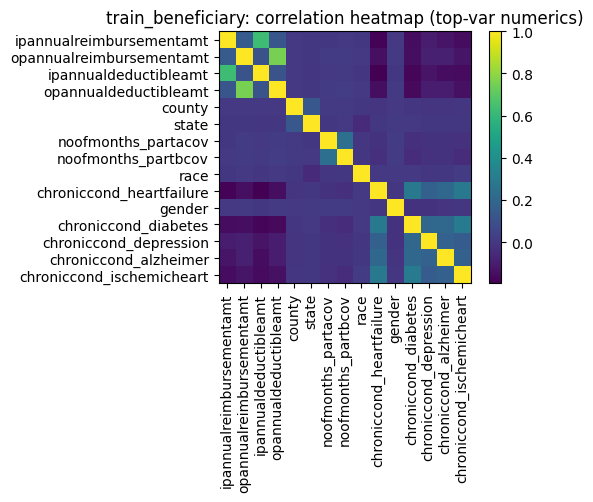


====================  train_inpatient  ====================
shape: 40,474 rows x 30 cols
duplicate rows: 0

-- dtypes summary --


,count,pct
float64,19,63.3
object,6,20.0
datetime64[ns],4,13.3
int64,1,3.3



-- top missing columns --


,missing_%
clmprocedurecode_6,100.00
clmprocedurecode_5,99.98
clmprocedurecode_4,99.71
clmprocedurecode_3,97.62
clmdiagnosiscode_10,91.43
otherphysician,88.41
clmprocedurecode_2,86.52
clmprocedurecode_1,42.81
operatingphysician,41.12
clmdiagnosiscode_9,40.58



-- date ranges --


...

operatingphysician
NaN          16644
PHY429430      225
PHY341560      153
PHY411541      121
PHY352941      110
PHY314410      109
PHY362864      107
PHY429828      104
PHY430367      101
PHY395464      100
Name: count, dtype: int64


[otherphysician] top values:


otherphysician
NaN          35784
PHY416093       81
PHY333406       38
PHY429929       30
PHY423728       29
PHY361563       29
PHY328051       24
PHY361104       23
PHY399458       22
PHY392443       20
Name: count, dtype: int64


-- numeric correlation (Pearson) --


,inscclaimamtreimbursed,clmadmitdiagnosiscode,deductibleamtpaid,diagnosisgroupcode,clmdiagnosiscode_1,clmdiagnosiscode_2,clmdiagnosiscode_3,clmdiagnosiscode_4,clmdiagnosiscode_5,clmdiagnosiscode_6,clmdiagnosiscode_7,clmdiagnosiscode_8,clmdiagnosiscode_9,clmdiagnosiscode_10,clmprocedurecode_1,clmprocedurecode_2,clmprocedurecode_3,clmprocedurecode_4,clmprocedurecode_5,clmprocedurecode_6
inscclaimamtreimbursed,1.000000,0.007322,NaN,0.027383,0.036256,0.018770,0.023157,0.023024,0.009320,0.007581,0.003827,0.017981,0.011712,-0.014252,-0.146004,0.108392,0.134871,-0.087345,0.662121,NaN
clmadmitdiagnosiscode,0.007322,1.000000,NaN,-0.039691,0.310436,0.003925,0.000674,0.001872,-0.005620,-0.006732,0.004926,-0.002498,0.007408,0.021244,0.035591,-0.028794,0.052884,0.137464,0.309607,NaN
deductibleamtpaid,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
diagnosisgroupcode,0.027383,-0.039691,NaN,1.000000,-0.060163,0.029557,0.032784,0.030790,0.023863,0.032374,0.032091,0.024428,0.026737,0.039874,0.218572,0.024505,0.085571,0.044304,-0.388174,NaN
clmdiagnosiscode_1,0.036256,0.310436,NaN,-0.060163,1.000000,0.005083,-0.003888,-0.008632,-0.002561,0.006027,0.002315,0.004864,-0.004291,0.012080,0.057224,-0.033417,-0.025420,0.107581,-0.349633,NaN
clmdiagnosiscode_2,0.018770,0.003925,NaN,0.029557,0.005083,1.000000,-0.002056,-0.008662,-0.010594,-0.000087,-0.010791,-0.010584,-0.009939,-0.060813,0.016130,-0.013663,-0.013705,0.043713,0.052994,NaN
clmdiagnosiscode_3,0.023157,0.000674,NaN,0.032784,-0.003888,-0.002056,1.000000,-0.004924,-0.005403,-0.006853,-0.005751,0.004077,-0.014962,0.024991,0.006209,0.007862,0.028658,-0.093256,-0.652687,NaN
clmdiagnosiscode_4,0.023024,0.001872,NaN,0.030790,-0.008632,-0.008662,-0.004924,1.000000,-0.009932,0.005086,-0.000317,0.000695,-0.008113,-0.017062,0.021292,0.001181,0.003083,0.123911,0.949768,NaN
clmdiagnosiscode_5,0.009320,-0.005620,NaN,0.023863,-0.002561,-0.010594,-0.005403,-0.009932,1.000000,-0.011356,0.002331,-0.001600,-0.005279,-0.006154,0.013842,0.020551,-0.007777,0.144276,-0.398644,NaN
clmdiagnosiscode_6,0.007581,-0.006732,NaN,0.032374,0.006027,-0.000087,-0.006853,0.005086,-0.011356,1.000000,-0.008315,-0.002751,0.002929,-0.007112,0.005370,-0.008333,0.082229,-0.140549,-0.505542,NaN


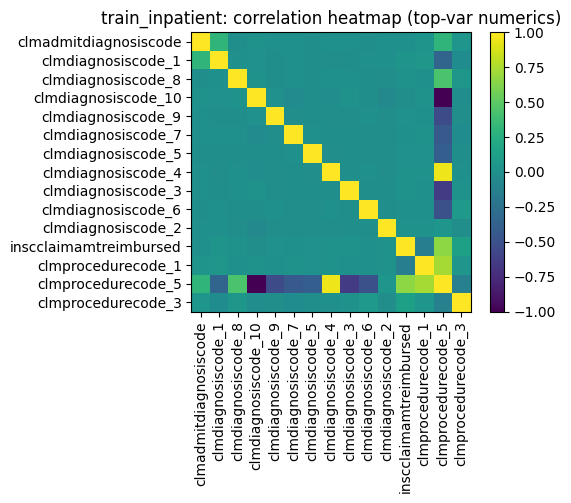


====================  train_outpatient  ====================
shape: 517,737 rows x 27 cols
duplicate rows: 0

-- dtypes summary --


,count,pct
float64,17,63.0
object,6,22.2
datetime64[ns],2,7.4
int64,2,7.4



-- top missing columns --


,missing_%
clmprocedurecode_6,100.00
clmprocedurecode_5,100.00
clmprocedurecode_4,100.00
clmprocedurecode_3,100.00
clmprocedurecode_2,99.99
clmprocedurecode_1,99.97
clmdiagnosiscode_10,99.84
clmdiagnosiscode_9,97.68
clmdiagnosiscode_8,96.41
clmdiagnosiscode_7,94.82



-- date ranges --


...

otherphysician
NaN          322691
PHY412132      1247
PHY341578      1098
PHY338032      1070
PHY337425      1041
PHY347064       806
PHY322092       771
PHY409965       744
PHY313818       730
PHY350277       682
Name: count, dtype: int64


[deductibleamtpaid] top values:


deductibleamtpaid
0      496701
100      4582
70       2420
60       2065
40       2045
80       2024
50       1969
20       1406
30       1336
90       1245
Name: count, dtype: int64


-- numeric correlation (Pearson) --


,inscclaimamtreimbursed,clmdiagnosiscode_1,clmdiagnosiscode_2,clmdiagnosiscode_3,clmdiagnosiscode_4,clmdiagnosiscode_5,clmdiagnosiscode_6,clmdiagnosiscode_7,clmdiagnosiscode_8,clmdiagnosiscode_9,clmdiagnosiscode_10,clmprocedurecode_1,clmprocedurecode_2,clmprocedurecode_3,clmprocedurecode_4,clmprocedurecode_5,clmprocedurecode_6,deductibleamtpaid,clmadmitdiagnosiscode
inscclaimamtreimbursed,1.000000,0.021513,0.013116,0.012192,0.012949,-0.005919,0.002783,0.006742,0.008937,-0.001603,-0.043718,-0.063064,0.190604,-0.651469,1.0,NaN,NaN,0.092015,0.027274
clmdiagnosiscode_1,0.021513,1.000000,0.062137,0.042831,0.044675,0.055360,0.042651,0.042245,0.046662,0.053388,0.014808,-0.105055,0.123215,-0.984551,1.0,NaN,NaN,0.008201,0.386478
clmdiagnosiscode_2,0.013116,0.062137,1.000000,0.012924,0.012888,0.009818,0.006369,0.014462,0.001732,0.028712,0.042345,0.116921,0.087729,-0.031136,-1.0,NaN,NaN,0.004597,0.043186
clmdiagnosiscode_3,0.012192,0.042831,0.012924,1.000000,0.002920,0.023827,0.012154,0.012297,0.018884,0.005575,0.043224,-0.105477,-0.084973,0.145692,1.0,NaN,NaN,0.002711,0.038958
clmdiagnosiscode_4,0.012949,0.044675,0.012888,0.002920,1.000000,0.008459,0.025108,0.006650,0.017660,0.016437,-0.024610,0.215191,0.057899,-0.683379,-1.0,NaN,NaN,0.003941,0.051835
clmdiagnosiscode_5,-0.005919,0.055360,0.009818,0.023827,0.008459,1.000000,0.012955,0.010594,0.018060,0.023700,-0.052071,-0.015954,0.198229,-0.837854,-1.0,NaN,NaN,0.000863,0.039211
clmdiagnosiscode_6,0.002783,0.042651,0.006369,0.012154,0.025108,0.012955,1.000000,0.008387,0.015199,0.031789,0.045826,-0.013372,0.181493,-0.941617,NaN,NaN,NaN,0.000646,0.047449
clmdiagnosiscode_7,0.006742,0.042245,0.014462,0.012297,0.006650,0.010594,0.008387,1.000000,0.000101,0.025032,0.056496,-0.119915,0.147395,0.296429,NaN,NaN,NaN,0.018731,0.050973
clmdiagnosiscode_8,0.008937,0.046662,0.001732,0.018884,0.017660,0.018060,0.015199,0.000101,1.000000,0.009580,0.064178,-0.080952,0.245183,NaN,NaN,NaN,NaN,0.006552,0.060482
clmdiagnosiscode_9,-0.001603,0.053388,0.028712,0.005575,0.016437,0.023700,0.031789,0.025032,0.009580,1.000000,-0.064899,0.063377,-0.131930,NaN,NaN,NaN,NaN,0.009574,-0.025450


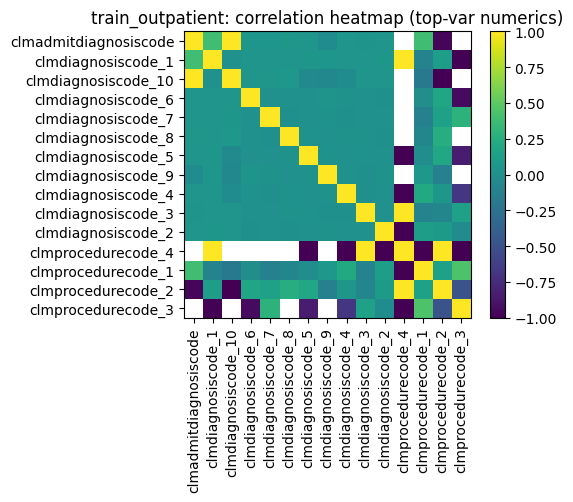


====================  train_labels  ====================
shape: 5,410 rows x 2 cols
duplicate rows: 0

-- dtypes summary --


,count,pct
object,2,100.0



-- top missing columns --


,missing_%
provider,0.0
potentialfraud,0.0



-- top categories (first 10 columns) --

[provider] top values:


...

chroniccond_cancer
2    55176
1     8792
Name: count, dtype: int64


[chroniccond_obstrpulmonary] top values:


chroniccond_obstrpulmonary
2    46447
1    17521
Name: count, dtype: int64


-- numeric correlation (Pearson) --


,gender,race,renaldiseaseindicator,state,county,noofmonths_partacov,noofmonths_partbcov,chroniccond_alzheimer,chroniccond_heartfailure,chroniccond_kidneydisease,chroniccond_cancer,chroniccond_obstrpulmonary,chroniccond_depression,chroniccond_diabetes,chroniccond_ischemicheart,chroniccond_osteoporasis,chroniccond_rheumatoidarthritis,chroniccond_stroke,ipannualreimbursementamt,ipannualdeductibleamt,opannualreimbursementamt,opannualdeductibleamt
gender,1.000000,0.005061,NaN,0.009510,0.007927,0.005554,0.007262,-0.017670,-0.005136,-0.005426,0.007811,-0.009430,-0.022473,-0.020966,-0.006320,-0.014517,-0.006053,-0.001869,0.004451,0.001865,0.006791,0.007728
race,0.005061,1.000000,NaN,-0.021600,0.001194,-0.009514,-0.005229,0.000052,0.001241,-0.003045,0.012714,0.002422,-0.007153,-0.000479,0.007602,0.008384,0.001746,0.000999,-0.002150,-0.003588,0.007950,0.005807
renaldiseaseindicator,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,0.009510,-0.021600,NaN,1.000000,0.200432,-0.002270,0.006279,0.011387,0.005502,0.008383,0.008881,0.001817,0.004838,0.008027,0.008669,0.010041,0.008031,0.005333,-0.011019,-0.011470,-0.017574,-0.018532
county,0.007927,0.001194,NaN,0.200432,1.000000,0.007694,0.006991,-0.010880,-0.016224,-0.015027,0.002189,-0.009218,-0.009781,-0.013601,-0.013018,-0.006459,-0.004536,-0.003908,0.005907,0.003445,0.001686,0.002565
noofmonths_partacov,0.005554,-0.009514,NaN,-0.002270,0.007694,1.000000,0.220714,-0.025492,-0.020972,-0.018862,-0.007674,-0.017174,-0.017266,-0.035725,-0.020771,-0.010738,-0.016967,-0.009727,-0.001923,0.005644,0.011089,0.012992
noofmonths_partbcov,0.007262,-0.005229,NaN,0.006279,0.006991,0.220714,1.000000,-0.018056,-0.028540,-0.025356,-0.009638,-0.018734,-0.026881,-0.045587,-0.029812,-0.019821,-0.020156,-0.010798,0.008851,0.013812,0.017748,0.016373
chroniccond_alzheimer,-0.017670,0.000052,NaN,0.011387,-0.010880,-0.025492,-0.018056,1.000000,0.197663,0.192454,0.048456,0.176701,0.177238,0.191816,0.157842,0.084187,0.095343,0.132673,-0.126718,-0.154740,-0.081820,-0.089070
chroniccond_heartfailure,-0.005136,0.001241,NaN,0.005502,-0.016224,-0.020972,-0.028540,0.197663,1.000000,0.311378,0.084654,0.261046,0.166145,0.283235,0.277659,0.090601,0.132667,0.134909,-0.186859,-0.194952,-0.144540,-0.154212
chroniccond_kidneydisease,-0.005426,-0.003045,NaN,0.008383,-0.015027,-0.018862,-0.025356,0.192454,0.311378,1.000000,0.113253,0.258873,0.171737,0.310601,0.244458,0.099108,0.149151,0.148481,-0.279707,-0.273647,-0.217105,-0.225768


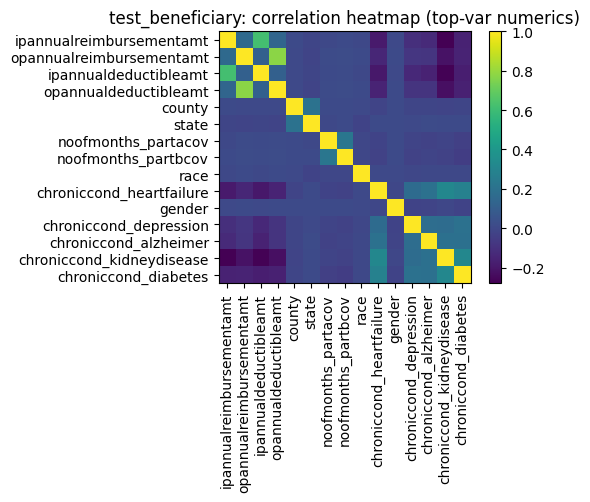


====================  test_inpatient  ====================
shape: 9,551 rows x 30 cols
duplicate rows: 0

-- dtypes summary --


,count,pct
float64,19,63.3
object,6,20.0
datetime64[ns],4,13.3
int64,1,3.3



-- top missing columns --


,missing_%
clmprocedurecode_6,100.00
clmprocedurecode_5,99.98
clmprocedurecode_4,99.70
clmprocedurecode_3,97.67
clmdiagnosiscode_10,91.90
otherphysician,89.39
clmprocedurecode_2,86.87
clmprocedurecode_1,43.12
operatingphysician,41.48
clmdiagnosiscode_9,40.90



-- date ranges --


...

operatingphysician
NaN          3962
PHY350998     170
PHY356259     170
PHY335869     139
PHY411861     135
PHY356145     112
PHY424915     106
PHY324672      98
PHY374216      96
PHY414941      90
Name: count, dtype: int64


[otherphysician] top values:


otherphysician
NaN          8538
PHY335869      38
PHY400576      21
PHY334783      16
PHY421759      15
PHY408074      10
PHY426107       9
PHY321461       9
PHY351219       8
PHY428648       8
Name: count, dtype: int64


-- numeric correlation (Pearson) --


,inscclaimamtreimbursed,clmadmitdiagnosiscode,deductibleamtpaid,diagnosisgroupcode,clmdiagnosiscode_1,clmdiagnosiscode_2,clmdiagnosiscode_3,clmdiagnosiscode_4,clmdiagnosiscode_5,clmdiagnosiscode_6,clmdiagnosiscode_7,clmdiagnosiscode_8,clmdiagnosiscode_9,clmdiagnosiscode_10,clmprocedurecode_1,clmprocedurecode_2,clmprocedurecode_3,clmprocedurecode_4,clmprocedurecode_5,clmprocedurecode_6
inscclaimamtreimbursed,1.000000,-0.005240,NaN,0.034529,0.024584,0.026730,0.011036,0.008847,0.021183,0.013275,-0.014582,0.026455,0.019745,-0.012533,-0.161168,0.105987,0.066883,0.139267,1.0,NaN
clmadmitdiagnosiscode,-0.005240,1.000000,NaN,-0.041888,0.287336,0.014381,0.021726,-0.000390,-0.015778,0.001865,0.010860,0.009748,0.005868,-0.030191,0.066915,-0.004641,-0.061727,0.119743,1.0,NaN
deductibleamtpaid,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
diagnosisgroupcode,0.034529,-0.041888,NaN,1.000000,-0.061325,0.013667,0.039222,0.049292,0.044265,0.036858,0.031659,0.019690,0.021099,0.050493,0.198263,0.067109,0.094498,0.047565,1.0,NaN
clmdiagnosiscode_1,0.024584,0.287336,NaN,-0.061325,1.000000,-0.016678,0.013186,-0.005419,-0.019177,-0.000047,-0.000412,0.016724,0.019845,0.011968,0.070741,-0.027859,-0.030452,-0.004065,-1.0,NaN
clmdiagnosiscode_2,0.026730,0.014381,NaN,0.013667,-0.016678,1.000000,-0.001795,0.000790,-0.017430,0.017089,0.015486,-0.006066,-0.015879,0.006522,0.009674,-0.002935,-0.085925,0.095189,NaN,NaN
clmdiagnosiscode_3,0.011036,0.021726,NaN,0.039222,0.013186,-0.001795,1.000000,-0.015133,-0.011304,-0.018513,-0.001227,0.005086,-0.000589,-0.025411,0.027580,0.002658,0.032120,-0.132026,NaN,NaN
clmdiagnosiscode_4,0.008847,-0.000390,NaN,0.049292,-0.005419,0.000790,-0.015133,1.000000,-0.019655,-0.012066,0.028890,-0.004273,0.010399,-0.096423,0.016280,-0.011262,0.113593,-0.203199,-1.0,NaN
clmdiagnosiscode_5,0.021183,-0.015778,NaN,0.044265,-0.019177,-0.017430,-0.011304,-0.019655,1.000000,-0.016573,0.025215,-0.011188,-0.005876,0.001004,-0.004034,0.008735,0.020944,-0.096152,-1.0,NaN
clmdiagnosiscode_6,0.013275,0.001865,NaN,0.036858,-0.000047,0.017089,-0.018513,-0.012066,-0.016573,1.000000,0.004096,0.002116,-0.004972,0.005063,0.018585,-0.017716,-0.049135,0.354156,-1.0,NaN


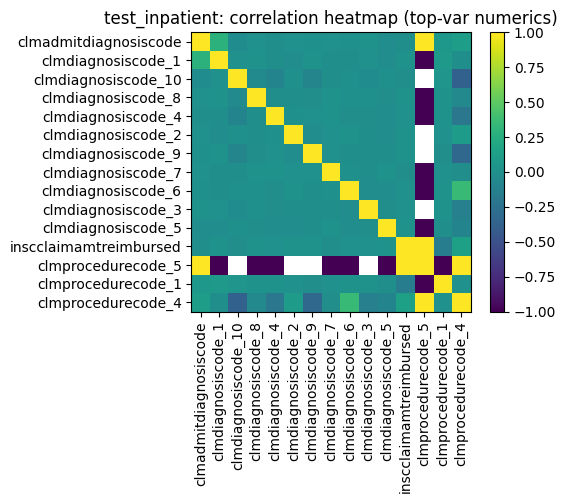


====================  test_outpatient  ====================
shape: 125,841 rows x 27 cols
duplicate rows: 0

-- dtypes summary --


,count,pct
float64,17,63.0
object,6,22.2
datetime64[ns],2,7.4
int64,2,7.4



-- top missing columns --


,missing_%
clmprocedurecode_6,100.00
clmprocedurecode_5,100.00
clmprocedurecode_4,100.00
clmprocedurecode_3,100.00
clmprocedurecode_2,99.99
clmprocedurecode_1,99.97
clmdiagnosiscode_10,99.84
clmdiagnosiscode_9,97.68
clmdiagnosiscode_8,96.39
clmdiagnosiscode_7,94.90



-- date ranges --


...

otherphysician
NaN          78222
PHY344080     1205
PHY378872      375
PHY347633      338
PHY353454      324
PHY333055      318
PHY347412      307
PHY385096      261
PHY359649      243
PHY410478      240
Name: count, dtype: int64


[deductibleamtpaid] top values:


deductibleamtpaid
0      120711
100      1115
70        598
50        520
40        512
80        488
60        483
20        345
30        317
10        291
Name: count, dtype: int64


-- numeric correlation (Pearson) --


,inscclaimamtreimbursed,clmdiagnosiscode_1,clmdiagnosiscode_2,clmdiagnosiscode_3,clmdiagnosiscode_4,clmdiagnosiscode_5,clmdiagnosiscode_6,clmdiagnosiscode_7,clmdiagnosiscode_8,clmdiagnosiscode_9,clmdiagnosiscode_10,clmprocedurecode_1,clmprocedurecode_2,clmprocedurecode_3,clmprocedurecode_4,clmprocedurecode_5,clmprocedurecode_6,deductibleamtpaid,clmadmitdiagnosiscode
inscclaimamtreimbursed,1.000000,0.026108,0.016166,0.015267,0.006653,-0.005355,-0.006641,-0.004192,0.026978,-0.012787,0.026051,0.058065,0.780470,1.0,NaN,NaN,NaN,0.140966,0.025208
clmdiagnosiscode_1,0.026108,1.000000,0.056228,0.064026,0.039541,0.065456,0.045129,0.047214,0.060573,0.065619,0.070801,0.116737,0.087578,-1.0,NaN,NaN,NaN,0.014208,0.375607
clmdiagnosiscode_2,0.016166,0.056228,1.000000,0.013533,0.010599,0.018229,0.011610,-0.008955,0.029773,0.008967,0.080498,0.037654,0.214635,1.0,NaN,NaN,NaN,0.006651,0.065441
clmdiagnosiscode_3,0.015267,0.064026,0.013533,1.000000,0.015041,0.017816,0.014278,0.021331,0.010982,0.016844,0.121767,0.248536,-0.484578,1.0,NaN,NaN,NaN,-0.002826,0.060193
clmdiagnosiscode_4,0.006653,0.039541,0.010599,0.015041,1.000000,0.022913,0.015410,0.029703,0.027231,0.045989,0.049275,0.160475,0.049228,-1.0,NaN,NaN,NaN,-0.001048,0.066498
clmdiagnosiscode_5,-0.005355,0.065456,0.018229,0.017816,0.022913,1.000000,0.018653,0.026391,0.005225,0.018504,0.096326,0.021898,-0.727355,-1.0,NaN,NaN,NaN,0.001672,0.015710
clmdiagnosiscode_6,-0.006641,0.045129,0.011610,0.014278,0.015410,0.018653,1.000000,0.030072,0.015317,0.028324,0.070886,0.113461,-0.179924,NaN,NaN,NaN,NaN,0.000805,0.031268
clmdiagnosiscode_7,-0.004192,0.047214,-0.008955,0.021331,0.029703,0.026391,0.030072,1.000000,0.010451,0.025425,0.063001,-0.212824,0.241312,-1.0,NaN,NaN,NaN,0.010125,0.015069
clmdiagnosiscode_8,0.026978,0.060573,0.029773,0.010982,0.027231,0.005225,0.015317,0.010451,1.000000,0.025819,-0.024243,-0.271656,0.894407,1.0,NaN,NaN,NaN,0.055178,0.069100
clmdiagnosiscode_9,-0.012787,0.065619,0.008967,0.016844,0.045989,0.018504,0.028324,0.025425,0.025819,1.000000,0.046030,0.057381,-0.016209,1.0,NaN,NaN,NaN,-0.006557,0.047992


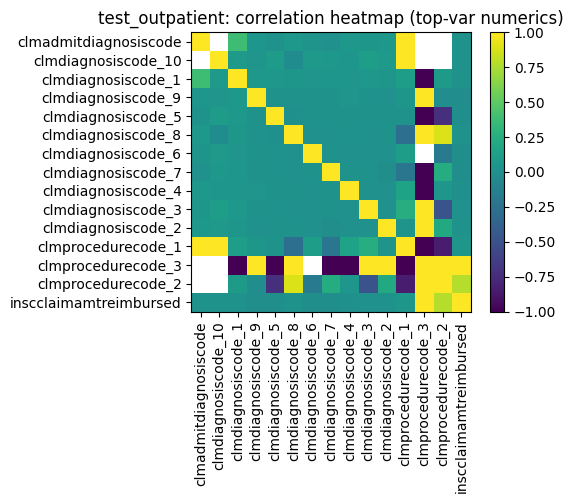


====================  test_labels  ====================
shape: 1,353 rows x 1 cols
duplicate rows: 0

-- dtypes summary --


,count,pct
object,1,100.0



-- top missing columns --


,missing_%
provider,0.0



-- top categories (first 10 columns) --

[provider] top values:


provider
PRV51002    1
PRV55422    1
PRV55484    1
PRV55478    1
PRV55476    1
PRV55466    1
PRV55461    1
PRV55457    1
PRV55440    1
PRV55429    1
Name: count, dtype: int64

In [12]:
eda_report(train_bene, "train_beneficiary")
eda_report(train_inp,  "train_inpatient")
eda_report(train_out,  "train_outpatient")
eda_report(train_lbl,  "train_labels")    # (usually has Provider + PotentialFraud)

eda_report(test_bene,  "test_beneficiary")
eda_report(test_inp,   "test_inpatient")
eda_report(test_out,   "test_outpatient")
eda_report(test_lbl,   "test_labels")     # (usually has only Provider)


#### Insights
**Beneficiary (train/test)**

- Coverage & demographics: ~84% integer cols, lots of flags; dob spans 1909–1983 → ages ~26–100 at 2009 (plausible Medicare-like).

- dod ~99% missing: normal (most beneficiaries didn’t die in 2009). Treat missing as “alive”.

- Part A/B months: almost always 12 with a small tail at 0/6/… → use as coverage stability features; treat 0 as genuine (not missing).

- Money fields: ip/op*_amt/deductible show heavy right tails, a few negative values (refund/adjustment). Plan outlier handling.

- Chronic conditions: values are 1/2 with 2 being majority. In the common Kaggle schema, that means 1=Yes, 2=No (counter-intuitive!). We should map 1→1, 2→0. (Your counts match that: “2” much larger for many conditions → most people don’t have the condition.)

- Correlations (bene):
    - Reasonable positive associations among chronic conditions (e.g., diabetes ↔ ischemic heart, COPD ↔ heart failure).
    - Moderate op/ip reimbursement ↔ op/ip deductible (0.75/0.63) → cost measures move together.
    - Near-zero with gender/race (as expected).

**Inpatient / Outpatient (train/test)**

- Date windows: late-2008 to 2009 — consistent across sets (good).

- Procedure codes: clmprocedurecode_3..6 mostly 100% missing, especially in outpatient. That’s normal: many claims don’t include CPT code slots beyond the first 1–2.

- Diagnosis codes: increasing missingness from diag_1 to diag_10 as slots run out — expected pattern.

- Physician columns: many NaN (e.g., otherphysician, operatingphysician) — keep as sparse categoricals or collapse to “Unknown”.

- Inpatient deductibleamtpaid is a constant 1068 for almost everyone → near-zero variance; either drop or keep as a check flag.

- Outpatient deductibleamtpaid is heavily zero-inflated with spikes at 100, 70, 60… (tariff-like). Useful as categorical/ordinal bins.

- Correlations:
    - Many wild ±1 values among clmprocedurecode_*/clmdiagnosiscode_* — that’s because these are codes (labels), not continuous quantities; Pearson on codes is not semantically meaningful and the ±1s often come from tiny non-missing slices. Don’t interpret these numerically — treat as categorical tokens.

### Target variable


-- target distribution: potentialfraud --


,count,pct
potentialfraud,,
No,4904,90.65
Yes,506,9.35


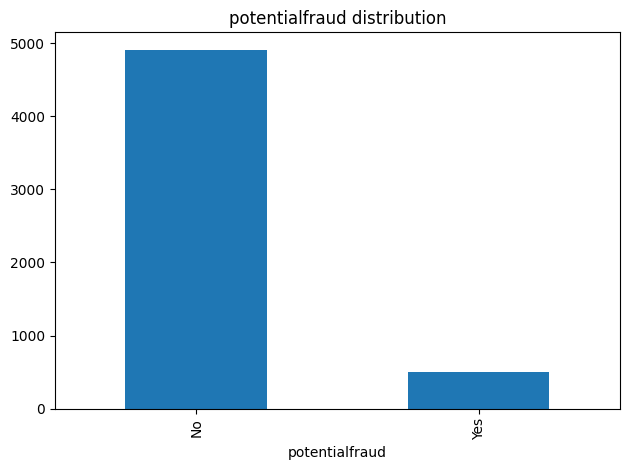

In [13]:
target_report(train_lbl, target_col="potentialfraud")

#### Insights
Class imbalance: No ~90.7%, Yes ~9.3% → classic fraud skew. You’ll want:
- stratified split / CV,
- PR-AUC reporting,
- class weights or focal loss,
- careful evaluation beyond accuracy

### Run on merged table


====================  train_merged  ====================
shape: 558,211 rows x 51 cols
duplicate rows: 0

-- dtypes summary --


,count,pct
int64,22,43.1
float64,19,37.3
object,6,11.8
datetime64[ns],4,7.8



-- top missing columns --


,missing_%
clmprocedurecode_6,100.00
clmprocedurecode_5,100.00
clmprocedurecode_4,99.98
clmprocedurecode_3,99.83
dod,99.26
clmdiagnosiscode_10,99.23
clmprocedurecode_2,99.02
clmprocedurecode_1,95.82
clmdiagnosiscode_9,93.54
clmdiagnosiscode_8,91.82



-- date ranges --


...

noofmonths_partacov
12    554722
0       2971
6        116
8        100
11        81
4         55
7         44
10        34
5         30
2         16
Name: count, dtype: int64


[noofmonths_partbcov] top values:


noofmonths_partbcov
12    553918
0       1979
6        728
10       402
11       313
9        242
8        142
7        139
5        126
3         73
Name: count, dtype: int64


-- numeric correlation (Pearson) --


,clmadmitdiagnosiscode,clmdiagnosiscode_1,clmdiagnosiscode_10,clmdiagnosiscode_2,clmdiagnosiscode_3,clmdiagnosiscode_4,clmdiagnosiscode_5,clmdiagnosiscode_6,clmdiagnosiscode_7,clmdiagnosiscode_8,clmdiagnosiscode_9,clmprocedurecode_1,clmprocedurecode_2,clmprocedurecode_3,clmprocedurecode_4,clmprocedurecode_5,clmprocedurecode_6,deductibleamtpaid,inscclaimamtreimbursed,gender,race,renaldiseaseindicator,state,county,noofmonths_partacov,noofmonths_partbcov,chroniccond_alzheimer,chroniccond_heartfailure,chroniccond_kidneydisease,chroniccond_cancer,chroniccond_obstrpulmonary,chroniccond_depression,chroniccond_diabetes,chroniccond_ischemicheart,chroniccond_osteoporasis,chroniccond_rheumatoidarthritis,chroniccond_stroke,ipannualreimbursementamt,ipannualdeductibleamt,opannualreimbursementamt,opannualdeductibleamt
clmadmitdiagnosiscode,1.000000,0.360540,0.021436,0.021221,0.013887,0.017404,0.005440,0.004450,0.012447,0.006472,0.003745,0.035758,-0.029352,0.052884,0.137464,0.309607,NaN,0.113261,0.074946,-0.001126,0.002099,NaN,0.000133,-0.002633,-0.000733,-0.003160,-0.013352,-0.019879,-0.019945,0.035338,-0.026191,-0.007675,-0.008659,-0.022381,-0.009769,-0.023343,-0.007909,0.053286,0.054416,0.013504,0.012113
clmdiagnosiscode_1,0.360540,1.000000,0.013606,0.054133,0.033176,0.030411,0.035545,0.028714,0.024260,0.025178,0.019579,0.056192,-0.032637,-0.030054,0.127303,-0.349633,NaN,0.029512,0.030092,0.004554,0.002680,NaN,-0.000425,0.001654,0.000849,-0.001416,-0.000125,0.000552,0.009936,0.037015,0.000849,-0.013819,-0.001926,-0.002429,-0.022017,-0.032959,0.002131,0.010544,0.009034,-0.014894,-0.012924
clmdiagnosiscode_10,0.021436,0.013606,1.000000,-0.039334,0.028788,-0.016891,-0.011351,0.006232,-0.014499,0.034207,-0.000947,0.019325,0.020015,-0.022629,0.583591,-1.000000,NaN,-0.053667,-0.034648,0.023234,-0.018090,NaN,-0.012294,-0.008959,0.009994,-0.004414,-0.003492,0.014693,0.013524,0.000822,0.015805,0.014215,-0.014565,-0.026879,-0.038809,-0.045170,0.022802,-0.026682,-0.017235,0.011125,0.025897
clmdiagnosiscode_2,0.021221,0.054133,-0.039334,1.000000,0.012066,0.009706,0.005682,0.006704,0.004490,-0.003170,0.006198,0.016943,-0.012988,-0.013165,0.018892,0.052994,NaN,-0.031243,-0.014212,0.001932,-0.002215,NaN,-0.002698,-0.001292,-0.000145,0.001639,0.006653,0.014815,0.010812,0.013333,0.011597,0.009287,0.007022,-0.000060,-0.024032,-0.018925,-0.000998,-0.007062,-0.008819,0.014656,0.016462
clmdiagnosiscode_3,0.013887,0.033176,0.028788,0.012066,1.000000,0.003281,0.017085,0.008072,0.006683,0.013249,-0.004774,0.005428,0.007079,0.027703,-0.062749,-0.652687,NaN,-0.038469,-0.016682,0.003216,-0.000513,NaN,-0.002053,0.002737,0.002585,0.001295,0.007211,0.006762,0.006889,0.009551,0.012877,0.005878,0.005701,0.001507,-0.021687,-0.016164,-0.000757,-0.005272,-0.007495,0.023165,0.024430
clmdiagnosiscode_4,0.017404,0.030411,-0.016891,0.009706,0.003281,1.000000,0.005076,0.019979,0.005738,0.010170,0.002885,0.022754,0.001716,0.004987,0.118365,0.949768,NaN,-0.041646,-0.016647,0.003001,-0.000400,NaN,0.000392,-0.001197,0.001413,0.001234,0.005724,0.014077,0.009381,0.011795,0.014706,0.005437,0.002991,0.004685,-0.022151,-0.013470,-0.002328,-0.007075,-0.013861,0.020456,0.019492
clmdiagnosiscode_5,0.005440,0.035545,-0.011351,0.005682,0.017085,0.005076,1.000000,0.006620,0.009787,0.009583,0.008231,0.013645,0.021618,-0.013724,0.133326,-0.398644,NaN,-0.051308,-0.027562,0.003070,0.003945,NaN,-0.001047,-0.007098,-0.002841,-0.003993,0.010712,0.016483,0.014660,0.013448,0.017401,0.007012,0.004683,0.005968,-0.018163,-0.011172,0.004591,-0.018165,-0.021893,0.004565,0.005129
clmdiagnosiscode_6,0.004450,0.028714,0.006232,0.006704,0.008072,0.019979,0.006620,1.000000,0.003757,0.008245,0.016183,0.005352,-0.006662,0.080966,-0.156802,-0.505542,NaN,-0.058508,-0.029187,0.004211,-0.006519,NaN,0.001875,0.003011,-0.004732,-0.009831,0.014389,0.019017,0.022351,0.009660,0.015975,0.005987,0.008932,0.006744,-0.012207,-0.011599,0.007195,-0.024876,-0.024234,0.010558,0.008088
clmdiagnosiscode_7,0.012447,0.024260,-0.014499

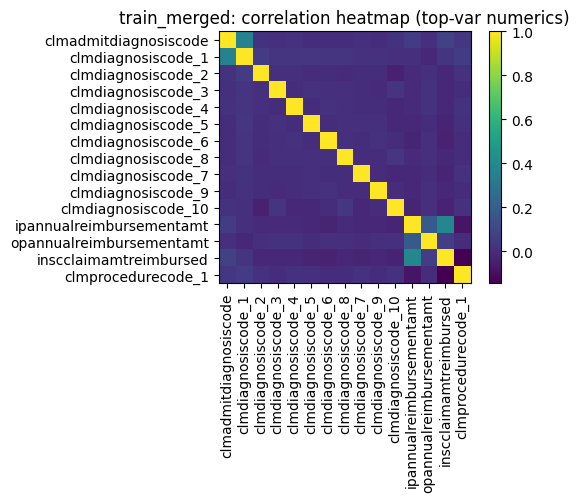


====================  test_merged  ====================
shape: 135,392 rows x 51 cols
duplicate rows: 0

-- dtypes summary --


,count,pct
int64,22,43.1
float64,19,37.3
object,6,11.8
datetime64[ns],4,7.8



-- top missing columns --


,missing_%
clmprocedurecode_6,100.00
clmprocedurecode_5,100.00
clmprocedurecode_4,99.98
clmprocedurecode_3,99.83
clmdiagnosiscode_10,99.28
dod,99.23
clmprocedurecode_2,99.07
clmprocedurecode_1,95.96
clmdiagnosiscode_9,93.67
clmdiagnosiscode_8,91.92



-- date ranges --


...

noofmonths_partacov
12    134524
0        733
8         30
11        26
6         25
4         16
9         12
7         10
5          7
10         4
Name: count, dtype: int64


[noofmonths_partbcov] top values:


noofmonths_partbcov
12    134405
0        442
6        155
11        97
10        71
9         69
5         43
8         36
7         24
3         16
Name: count, dtype: int64


-- numeric correlation (Pearson) --


,clmadmitdiagnosiscode,clmdiagnosiscode_1,clmdiagnosiscode_10,clmdiagnosiscode_2,clmdiagnosiscode_3,clmdiagnosiscode_4,clmdiagnosiscode_5,clmdiagnosiscode_6,clmdiagnosiscode_7,clmdiagnosiscode_8,clmdiagnosiscode_9,clmprocedurecode_1,clmprocedurecode_2,clmprocedurecode_3,clmprocedurecode_4,clmprocedurecode_5,clmprocedurecode_6,deductibleamtpaid,inscclaimamtreimbursed,gender,race,renaldiseaseindicator,state,county,noofmonths_partacov,noofmonths_partbcov,chroniccond_alzheimer,chroniccond_heartfailure,chroniccond_kidneydisease,chroniccond_cancer,chroniccond_obstrpulmonary,chroniccond_depression,chroniccond_diabetes,chroniccond_ischemicheart,chroniccond_osteoporasis,chroniccond_rheumatoidarthritis,chroniccond_stroke,ipannualreimbursementamt,ipannualdeductibleamt,opannualreimbursementamt,opannualdeductibleamt
clmadmitdiagnosiscode,1.000000,0.345941,-0.030191,0.038788,0.035762,0.021700,-0.008892,0.007777,0.010751,0.018256,0.009749,0.067414,-0.005392,-0.061727,0.119743,1.0,NaN,0.109260,0.066883,-0.002153,-0.002458,NaN,0.012324,0.002314,0.005204,-0.004490,-0.008888,-0.016812,-0.012931,0.018670,-0.018310,0.003476,-0.010771,-0.019223,-0.000380,-0.011125,-0.002641,0.039806,0.055313,0.006915,0.009139
clmdiagnosiscode_1,0.345941,1.000000,0.025126,0.046741,0.054503,0.028477,0.038524,0.027723,0.026514,0.041119,0.041475,0.071147,-0.027011,-0.036628,-0.004065,-1.0,NaN,0.021450,0.023551,0.008679,-0.002740,NaN,0.006411,-0.000859,0.001616,-0.002402,-0.002732,0.008227,0.013554,0.037298,0.005287,-0.012584,0.003383,0.001349,-0.014536,-0.025602,0.003952,0.005535,0.005157,-0.015301,-0.011256
clmdiagnosiscode_10,-0.030191,0.025126,1.000000,0.025161,0.006799,-0.064704,0.019502,0.018208,0.011329,-0.043250,-0.063006,0.048133,-0.149371,0.338702,-0.375465,NaN,NaN,-0.034672,-0.021698,0.044031,0.006883,NaN,0.046132,-0.031050,-0.000889,0.034505,0.038313,0.001085,0.008209,0.018798,-0.003370,-0.017788,-0.012796,0.008106,-0.017386,0.034015,-0.034304,0.016802,-0.037182,0.010396,0.011693
clmdiagnosiscode_2,0.038788,0.046741,0.025161,1.000000,0.012637,0.010463,0.009283,0.016315,0.005187,0.012285,-0.004352,0.009936,-0.002058,-0.086085,0.095189,NaN,NaN,-0.032501,-0.012310,-0.001400,-0.003376,NaN,-0.003221,-0.004379,0.000060,0.005437,-0.003181,0.010016,0.002390,0.017918,0.014526,0.007987,0.007080,0.000994,-0.016319,-0.015927,-0.006115,-0.003191,-0.007551,0.026160,0.026662
clmdiagnosiscode_3,0.035762,0.054503,0.006799,0.012637,1.000000,0.010124,0.011833,0.003700,0.013350,0.011236,0.009527,0.028724,0.000790,0.051304,-0.132026,NaN,NaN,-0.036323,-0.018181,-0.006664,0.005387,NaN,0.002103,0.002909,-0.001081,0.007127,0.006072,0.004737,0.009563,0.004746,0.012451,-0.002116,0.004031,0.001320,-0.019244,-0.016123,-0.002498,-0.005866,-0.002396,0.019839,0.018688
clmdiagnosiscode_4,0.021700,0.028477,-0.064704,0.010463,0.010124,1.000000,0.012346,0.006590,0.032407,0.011801,0.027471,0.017180,-0.010462,0.104622,-0.203199,-1.0,NaN,-0.042832,-0.022713,-0.000005,-0.003150,NaN,-0.001072,-0.009305,0.002371,-0.011082,0.009373,0.017632,0.012470,0.002782,0.023185,0.004199,0.002717,-0.001871,-0.017829,-0.015561,0.008549,-0.019005,-0.022916,0.020095,0.021994
clmdiagnosiscode_5,-0.008892,0.038524,0.019502,0.009283,0.011833,0.012346,1.000000,0.007450,0.028685,-0.000192,0.006165,-0.004057,0.006724,0.020767,-0.096152,-1.0,NaN,-0.058817,-0.026696,-0.009520,0.002305,NaN,0.000639,-0.006658,-0.002992,0.008889,0.000514,0.018985,0.011769,0.008180,0.026429,0.000944,0.009072,0.003761,-0.022635,-0.020369,0.001635,-0.016906,-0.025928,0.006824,0.008035
clmdiagnosiscode_6,0.007777,0.027723,0.018208,0.016315,0.003700,0.006590,0.007450,1.000000,0.018997,0.010627,0.010652,0.019080,-0.018259,-0.054896,0.354156,-1.0,NaN,-0.044491,-0.019506,0.018458,-0.005216,NaN,-0.020457,-0.015790,0.004353,0.005063,0.004050,0.012594,0.009607,0.006477,0.014158,-0.000800,-0.001793,0.006538,-0.022982,-0.013272,0.000538,-0.020746,-0.023313,-0.003422,0.004864
clmdiagnosiscode_7,0.010751,0.026514,0.011329,0.005187,0.013350,0.032407,0.028685

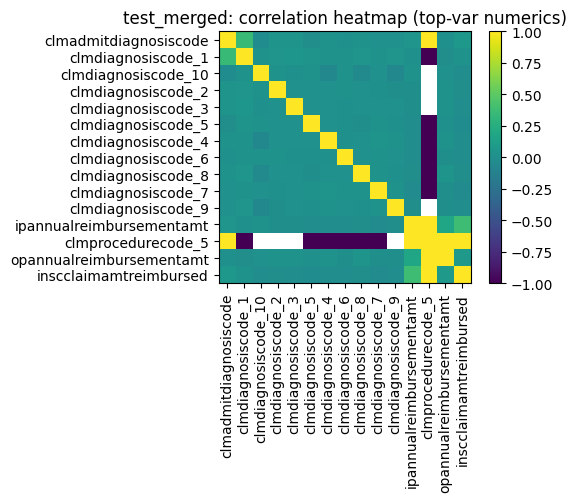

In [14]:
try:
    eda_report(train_merged, "train_merged")
    eda_report(test_merged,  "test_merged")
except NameError:
    print("Merged tables not found. Skip.")

#### Insights
**Quick health check:**
- Rows/cols: train 558,211×51; test 135,392×51. No duplicates.
- Time bounds: claims span late-2008 → 2009. Use absolute dates (YYYY-MM-DD) and derive claim year/quarter/month.
- Ages: DOB 1909–1983 ⇒ ages ~26–100 in 2009. Create age at claim (floor((claimstartdt-dob)/365.25)), and optionally age buckets.
- Massive sparsity: procedure slots 2–6 are ~99–100% missing; diagnosis slots 5–10 are 83–99% missing. Treat these as variable-length lists: don’t impute code IDs; instead engineer counts/presence.
- DOD ~99% missing. Interpret as “alive/not recorded” and derive a deceased flag + days from claim to DOD where present; otherwise drop raw dod.

**Leakage + semantics to watch**

- Annual totals (ipannual*, opannual*) are same-year aggregates. If your target is claim-level payment (inscclaimamtreimbursed) they may include information computed after the claim—potential leakage. If you keep them, ensure they’re built from prior claims only (lagged, patient-level).
- Chronic condition flags sit around 1.4–1.9 mean, which suggests CMS encoding (1 = Yes, 2 = No). Remap to binary (1→1, 2→0) before modeling; treating them as numeric 1/2 will invert meanings and blur correlations.
- State and county are categorical codes, not ordinals—encode accordingly.

**Missingness & what to do**

- Drop outright (very safe): clmprocedurecode_6 (100% missing), clmprocedurecode_5 (~100%), clmprocedurecode_4 (~100%), clmprocedurecode_3 (~99.8%).
- Same for clmdiagnosiscode_10 (~99%) unless you plan sparse sequence features.

**Engineer instead of imputing codes:**

- diag_count = number of non-null diagnosis slots.

- proc_count = number of non-null procedure slots.

- Top-K code presence: make binary features for the top ~50–200 most frequent diagnosis/procedure codes (across all slots).

- Any_surgical/any_ED flags if you can map code groups.

- Physician fields (operatingphysician, otherphysician) ~65–80%+ missing. Useful as presence flags and high-cardinality categories (target/frequency encoding). Consider provider/physician-level aggregates (see below).

**Distributions & oddities**

- Reimbursed amounts (inscclaimamtreimbursed) are extremely right-skewed with big outliers (up to 125k). Use log1p or robust losses; cap outliers.

- Deductibles: deductibleamtpaid and annual deductibles have a prominent spike at 1068 (plan max). Keep as numeric; consider is_max_deductible flag.

- Negative amounts: ipannualreimbursementamt/opannualreimbursementamt have negatives (refunds/adjustments). Keep but maybe add has_refund flags.

- Weird perfect correlations: clmprocedurecode_5 shows ±1 correlations in both splits—this is an artifact of tiny non-null counts. Best to drop raw column and only use counts/presence features.

**Train vs test drift**

- Missingness patterns, central tendencies, and category shares are very similar across splits. Top providers/physicians differ (expected), but macro stats match. No obvious covariate shift.

**Categorical high-cardinality plan**

- IDs: provider, attendingphysician, operatingphysician, otherphysician, beneid, claimid.

    - Don’t one-hot. Use target/frequency encoding (with CV folds to avoid leakage).

    - Build entity aggregates from training only: e.g., per-provider mean reimburse, claim volume, mix of IP/OP, average diag/proc counts, historical denial/refund rate if available.

- Geography: one-hot (top states) + frequency encoding for county. Add state×urbanicity if you can map FIPS→urban/rural.

**Date features**

- length_of_stay proxy: claimenddt - claimstartdt (days, clipped ≥0).

- Seasonality: month, quarter, day-of-week (for outpatient).

- Patient trajectory: per-bene rolling counts/totals prior to claim date (30/90/365-day windows): number of claims, sum reimbursed, average deductible, prior IP admission flag, prior specific diagnosis presence.

**Numeric features**

- After remapping chronic flags to 0/1, many should positively relate to spend. Current correlations are muted by 1/2 encoding.

- gender ≈ 58% female; race dominated by code 1. Treat as categorical (not ordinal).

## Feature Engineering (Leakage-Safe)

This section builds rich and reliable features for fraud detection while avoiding **data leakage**.

The workflow has **two parts**:


**1. `create_all_features()` — Core, Label-Free Features**

Creates all **non-leaky, deterministic features** from claim, beneficiary, and physician data.

*Key Feature Groups*

| Group | Example Columns | Description |
|--------|-----------------|--------------|
| **Temporal** | `Age_at_Claim`, `ClaimMonth`, `LOS_Days`, `Claim_Date_Mismatch` | Captures timing, seasonality, and consistency of claims |
| **Health & Diagnosis** | `Diagnosis_Count`, `Procedure_Count`, `Diagnosis_Unique_Count`, `Proc_Diag_Ratio` | Medical code diversity and claim complexity |
| **Financial** | `InscClaimAmtReimbursed_arcsinh`, `IP_Reimb_Deduct_Ratio`, `DeductibleAmtPaid_Is1068` | Claim cost structure and outlier patterns |
| **Physician Presence** | `Has_AttendingPhysician`, `Has_OperatingPhysician` | Detects missing or unusual physician data |
| **Mortality Flags** | `Deceased_Flag`, `Days_Claim_to_DOD` | Captures end-of-life health signals |
| **Top-K Code Indicators** | `HasDiag_4019`, `HasProc_99213`, etc. | Sparse presence flags for most frequent diagnosis/procedure codes |

*Transformations and Ratios*
- `arcsinh(x)` and `log1p(x)` used for long-tailed cost data.
- Ratios between reimbursements and deductibles (e.g., `IP_Reimb_Deduct_Ratio`).
- Negative-amount and deductible-spike (1068) flags.
- Seasonality (year, quarter, month, weekday).
- Length of stay, and date mismatch indicators.


**2. `make_oof_and_test_features()` — Leakage-Safe Aggregates**

Computes powerful **group-based and target-encoded** statistics **safely** using CV folds.

*Why This Matters*
Blocks VI and VII (physician/provider aggregates) can leak target info if calculated on the full dataset.  
To prevent this:
- We compute **out-of-fold (OOF)** features for training.
- We compute **full-train** versions only when applying to test data.

*Features Created*

| Group | Example Columns | Description |
|--------|-----------------|--------------|
| **VI. Frequency Encodings** | `Provider_Total_Claims`, `Provider_Mean_Reimbursed`, `AttendingPhysician_Total_Claims` | Volume & activity of providers and physicians |
| **VII. Target Encoded (Fraud Ratios)** | `Provider_Fraud_Ratio`, `AttendingPhysician_Fraud_Ratio` | Fraction of fraudulent claims per provider/physician, computed out-of-fold |
| **Smoothed Ratios** | `(fraud + prior * k) / (total + k)` | Stabilizes rare IDs using a global prior |

*Leakage Safety*

| Dataset | Computation | Notes |
|----------|--------------|-------|
| **Train** | Out-of-fold (OOF) CV with `StratifiedKFold` or `GroupKFold` | Prevents label look-ahead |
| **Test** | Fit on full training set, then apply | Simulates production inference |
| **Groups** | Use `GroupKFold` by `BeneID` | Prevents the same beneficiary appearing in both train and validation |


**3. Example Usage**

```python
# Base features (no leakage)
train_base = create_all_features(train_df, include_id_counts=False, include_fraud_ratios=False)
test_base  = create_all_features(test_df,  include_id_counts=False, include_fraud_ratios=False)

# Add leakage-safe ID counts & fraud ratios
train_ready, test_ready = make_oof_and_test_features(
    train_base, test_base,
    id_cols=('AttendingPhysician','OperatingPhysician','OtherPhysician','Provider'),
    y_col='PotentialFraud',
    n_splits=5,
    group_col='BeneID'  # recommended to avoid patient leakage
)

# Model training
# Use train_ready for training, test_ready for inference


In [23]:
# ================================
# Feature Engineering (Leakage-Safe) — lowercase schema
# ================================
from collections import defaultdict
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, GroupKFold

EPSILON = 1e-6

def _lowercase_cols(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out.columns = out.columns.str.lower().str.strip()
    return out

# ------------------------------------------------------------
# (1) Baseline feature builder (label-free by default)
# ------------------------------------------------------------
def create_all_features(
    full_df: pd.DataFrame,
    topk_diag: int = 50,
    topk_proc: int = 25,
    add_topk_presence: bool = True,
    # Leakage-prone blocks (keep False for modeling; use helpers below)
    include_id_counts: bool = False,     # VI: *_total_claims, provider_mean_reimbursed
    include_fraud_ratios: bool = False   # VII: *_fraud_claims, *_fraud_ratio (uses labels)
) -> pd.DataFrame:
    """
    Applies feature engineering to the DataFrame (expects lowercase columns).
    """
    df = _lowercase_cols(full_df)

    # === I. Date Conversion (Prereq) ===
    date_columns = ['claimstartdt', 'claimenddt', 'admissiondt', 'dischargedt', 'dob', 'dod']
    for col in date_columns:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors='coerce')

    # === II. Binary Conversions ===
    if 'potentialfraud' in df.columns:
        # map Yes/No to 1/0 if still strings; leave ints if already 0/1
        if df['potentialfraud'].dtype == object:
            df['potentialfraud'] = df['potentialfraud'].map({'Yes': 1, 'No': 0, 'yes': 1, 'no': 0})
    chronic_cols = [c for c in df.columns if c.startswith('chroniccond_')]
    if chronic_cols:
        df[chronic_cols] = df[chronic_cols].replace(2, 0)

    # === III. Time & Flags ===
    if {'claimstartdt', 'dob'}.issubset(df.columns):
        age_days = (df['claimstartdt'] - df['dob']).dt.days
        df['age_at_claim'] = np.where(age_days.notna(), np.floor(age_days / 365.25), np.nan)
        df.loc[df['age_at_claim'] < 0, 'age_at_claim'] = np.nan

    if 'claimstartdt' in df.columns:
        df['claimyear']    = df['claimstartdt'].dt.year
        df['claimquarter'] = df['claimstartdt'].dt.quarter
        df['claimmonth']   = df['claimstartdt'].dt.month
        df['claimdow']     = df['claimstartdt'].dt.weekday  # 0=Mon

    if {'claimstartdt', 'claimenddt'}.issubset(df.columns):
        los = (df['claimenddt'] - df['claimstartdt']).dt.days
        df['los_days'] = los.clip(lower=0)

    if {'admissiondt', 'dischargedt', 'claimstartdt', 'claimenddt'}.issubset(df.columns):
        df['claim_date_mismatch'] = np.where(
            (df['admissiondt'] > df['claimstartdt']) | (df['dischargedt'] < df['claimenddt']),
            1, 0
        )

    if {'dod', 'claimenddt'}.issubset(df.columns):
        df['deceased_flag']     = df['dod'].notna().astype(int)
        df['days_claim_to_dod'] = (df['dod'] - df['claimenddt']).dt.days

    for pcol in ['attendingphysician', 'operatingphysician', 'otherphysician']:
        if pcol in df.columns:
            df[f'has_{pcol}'] = df[pcol].notna().astype(int)

    # === IV. Count-based Features ===
    diag_cols = [f'clmdiagnosiscode_{i}' for i in range(1, 11) if f'clmdiagnosiscode_{i}' in df.columns]
    proc_cols = [f'clmprocedurecode_{i}' for i in range(1, 7) if f'clmprocedurecode_{i}' in df.columns]

    if diag_cols:
        df['diagnosis_count'] = df[diag_cols].notna().sum(axis=1)
        df['diagnosis_unique_count'] = df[diag_cols].apply(lambda r: r.dropna().nunique(), axis=1)
    else:
        df['diagnosis_count'] = 0
        df['diagnosis_unique_count'] = 0

    if proc_cols:
        df['procedure_count'] = df[proc_cols].notna().sum(axis=1)
        df['procedure_unique_count'] = df[proc_cols].apply(lambda r: r.dropna().nunique(), axis=1)
    else:
        df['procedure_count'] = 0
        df['procedure_unique_count'] = 0

    df['proc_diag_ratio'] = df['procedure_count'] / (df['diagnosis_count'] + EPSILON)

    # === V. Numeric transforms, ratios, flags ===
    for col in ['inscclaimamtreimbursed', 'deductibleamtpaid',
                'ipannualreimbursementamt', 'opannualreimbursementamt']:
        if col in df.columns:
            df[f'{col}_arcsinh'] = np.arcsinh(df[col])

    for col in ['inscclaimamtreimbursed', 'deductibleamtpaid',
                'ipannualreimbursementamt', 'opannualreimbursementamt',
                'ipannualdeductibleamt', 'opannualdeductibleamt']:
        if col in df.columns:
            df[f'{col}_log1p'] = np.log1p(df[col].clip(lower=0))

    if {'ipannualreimbursementamt', 'ipannualdeductibleamt'}.issubset(df.columns):
        df['ip_reimb_deduct_ratio'] = df['ipannualreimbursementamt'] / (df['ipannualdeductibleamt'] + EPSILON)
    if {'opannualreimbursementamt', 'opannualdeductibleamt'}.issubset(df.columns):
        df['op_reimb_deduct_ratio'] = df['opannualreimbursementamt'] / (df['opannualdeductibleamt'] + EPSILON)

    for col in ['ipannualreimbursementamt', 'opannualreimbursementamt']:
        if col in df.columns:
            df[f'{col}_hasrefund'] = (df[col] < 0).astype(int)

    for col in ['ipannualdeductibleamt', 'opannualdeductibleamt', 'deductibleamtpaid']:
        if col in df.columns:
            df[f'{col}_is1068'] = (df[col] == 1068).astype(int)
    if {'ipannualdeductibleamt', 'opannualdeductibleamt', 'deductibleamtpaid'}.issubset(df.columns):
        df['any_max_deductible_1068'] = (
            (df['ipannualdeductibleamt'] == 1068) |
            (df['opannualdeductibleamt'] == 1068) |
            (df['deductibleamtpaid'] == 1068)
        ).astype(int)

    # === VI. ID counts & simple aggregates (OPTIONAL; leakage-safe fit provided below) ===
    if include_id_counts:
        id_like_cols = []
        for col in ['provider', 'attendingphysician', 'operatingphysician', 'otherphysician', 'state', 'county']:
            if col in df.columns:
                id_like_cols.append(col)

        for col in id_like_cols:
            counts = df.groupby(col)['claimid'].nunique().rename(f'{col}_total_claims')
            df = df.merge(counts, on=col, how='left')

        if {'provider', 'claimid'}.issubset(df.columns) and 'inscclaimamtreimbursed' in df.columns:
            prov_mean_reimb = df.groupby('provider')['inscclaimamtreimbursed'].mean().rename('provider_mean_reimbursed')
            df = df.merge(prov_mean_reimb, on='provider', how='left')

    # === VII. Fraud ratios (OPTIONAL; DO NOT USE DIRECTLY FOR MODELING) ===
    if include_fraud_ratios and 'potentialfraud' in df.columns:
        fraud_df_temp = df[df['potentialfraud'] == 1].copy()
        for col in ['attendingphysician', 'operatingphysician', 'otherphysician', 'provider']:
            if col in df.columns:
                total_claims_count = df.groupby(col)['claimid'].nunique().rename(f'{col}_total_claims_fr')
                df = df.merge(total_claims_count, on=col, how='left')
                fraud_claims_count = fraud_df_temp.groupby(col)['claimid'].nunique().rename(f'{col}_fraud_claims')
                df = df.merge(fraud_claims_count, on=col, how='left')
                df[f'{col}_fraud_claims'] = df[f'{col}_fraud_claims'].fillna(0)
                df[f'{col}_fraud_ratio'] = (
                    df[f'{col}_fraud_claims'] / (df[f'{col}_total_claims_fr'] + EPSILON)
                )
                df[f'{col}_fraud_ratio'] = df[f'{col}_fraud_ratio'].replace([np.inf, -np.inf], 0)

    # === VIII. Top-K code presence (sparse-friendly) ===
    if add_topk_presence and (diag_cols or proc_cols):
        if diag_cols:
            s = df[diag_cols].astype(str).stack()
            s = s[s.ne('nan')]
            top_diag = s.value_counts().head(topk_diag).index.tolist()
            for code in top_diag:
                df[f'hasdiag_{code}'] = (df[diag_cols].astype(str).eq(code).any(axis=1)).astype(int)

        if proc_cols:
            s = df[proc_cols].astype(str).stack()
            s = s[s.ne('nan')]
            top_proc = s.value_counts().head(topk_proc).index.tolist()
            for code in top_proc:
                df[f'hasproc_{code}'] = (df[proc_cols].astype(str).eq(code).any(axis=1)).astype(int)

    # === IX. Cleanup ===
    df = df.replace([np.inf, -np.inf], np.nan)
    return df


# ------------------------------------------------------------
# (2) Leakage-safe encoders for blocks VI & VII
# ------------------------------------------------------------
def _merge_map(df, key, series, name):
    mapper = series.rename(name)
    return df.merge(mapper, left_on=key, right_index=True, how='left')

def fit_unsupervised_stats(train_df, id_cols):
    """
    Label-free stats on TRAIN ONLY:
      - *_total_claims
      - provider_mean_reimbursed (if available)
    """
    df = _lowercase_cols(train_df)
    stats = {}
    for col in id_cols:
        if col in df.columns:
            total = df.groupby(col)['claimid'].nunique()
            stats[(col, 'total_claims')] = total

    if ('provider' in id_cols) and ('inscclaimamtreimbursed' in df.columns):
        prov_mean = df.groupby('provider')['inscclaimamtreimbursed'].mean()
        stats[('provider', 'mean_reimbursed')] = prov_mean

    return stats

def apply_unsupervised_stats(df, stats, id_cols):
    out = _lowercase_cols(df)
    for col in id_cols:
        if (col, 'total_claims') in stats:
            out = _merge_map(out, col, stats[(col, 'total_claims')], f'{col}_total_claims')
    if ('provider', 'mean_reimbursed') in stats:
        out = _merge_map(out, 'provider', stats[('provider', 'mean_reimbursed')], 'provider_mean_reimbursed')
    return out

def fit_supervised_stats(train_df, id_cols, y_col='potentialfraud', min_count=1, prior=None):
    """
    Label-based (supervised) stats on TRAIN ONLY:
      - *_fraud_claims
      - *_total_claims_fr
      - *_fraud_ratio (smoothed)
    """
    df = _lowercase_cols(train_df)
    sup = {}
    global_prior = df[y_col].mean() if prior is None else prior
    k = min_count  # smoothing

    for col in id_cols:
        if col not in df.columns:
            continue
        grp = df.groupby(col).agg(
            **{
                f'{col}_fraud_claims': (y_col, 'sum'),
                f'{col}_total_claims_fr': ('claimid', 'nunique'),
            }
        )
        ratio = (grp[f'{col}_fraud_claims'] + global_prior * k) / (grp[f'{col}_total_claims_fr'] + k)
        grp[f'{col}_fraud_ratio'] = ratio
        sup[col] = grp

    return sup, global_prior

def apply_supervised_stats(df, sup_stats, id_cols, global_prior):
    out = _lowercase_cols(df)
    for col in id_cols:
        if col in sup_stats:
            out = out.merge(sup_stats[col], left_on=col, right_index=True, how='left')
            out[f'{col}_fraud_claims']    = out.get(f'{col}_fraud_claims', 0).fillna(0)
            out[f'{col}_total_claims_fr'] = out.get(f'{col}_total_claims_fr', 0).fillna(0)
            out[f'{col}_fraud_ratio']     = out.get(f'{col}_fraud_ratio', global_prior).fillna(global_prior)
    return out

def make_oof_and_test_features(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    id_cols=('attendingphysician','operatingphysician','otherphysician','provider'),
    y_col='potentialfraud',
    n_splits=5,
    group_col=None,        # e.g., 'beneid' to GroupKFold; else StratifiedKFold
    random_state=42
):
    """
    Build leakage-safe versions of blocks VI (ID counts) and VII (fraud ratios).
      - Train: Out-of-fold (OOF) features.
      - Test: Fit on full train, apply to test.
    Returns:
      train_oof, test_feat
    """
    train_df = _lowercase_cols(train_df)
    test_df  = _lowercase_cols(test_df)

    # Prepare OOF container
    oof_add = pd.DataFrame(index=train_df.index)

    # CV splitter
    if group_col is not None:
        splitter = GroupKFold(n_splits=n_splits).split(
            train_df, train_df[y_col], groups=train_df[group_col]
        )
    else:
        splitter = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state).split(
            train_df, train_df[y_col]
        )

    # ---- OOF generation ----
    for tr_idx, va_idx in splitter:
        tr, va = train_df.iloc[tr_idx], train_df.iloc[va_idx]

        # VI: ID counts & provider mean reimbursed (label-free)
        unsup_stats = fit_unsupervised_stats(tr, id_cols)
        va_unsup    = apply_unsupervised_stats(va, unsup_stats, id_cols)

        # VII: target-encoded fraud ratios
        sup_stats, prior = fit_supervised_stats(tr, id_cols, y_col=y_col)
        va_sup = apply_supervised_stats(va_unsup, sup_stats, id_cols, prior)

        # Keep only new columns from this fold
        new_cols = [c for c in va_sup.columns if c not in train_df.columns]
        oof_add.loc[va_idx, new_cols] = va_sup[new_cols]

    train_oof = pd.concat([train_df, oof_add], axis=1)

    # ---- Final fit on FULL train; apply to TEST ----
    unsup_stats_full = fit_unsupervised_stats(train_df, id_cols)
    test_unsup = apply_unsupervised_stats(test_df, unsup_stats_full, id_cols)

    sup_stats_full, prior_full = fit_supervised_stats(train_df, id_cols, y_col=y_col)
    test_feat = apply_supervised_stats(test_unsup, sup_stats_full, id_cols, prior_full)

    # ---- Fill NAs for newly created cols ----
    def _fill_new(df_new, df_base):
        new_cols_all = [c for c in df_new.columns if c not in df_base.columns]
        if not new_cols_all:
            return df_new
        fill_map = {}
        for c in new_cols_all:
            if c.endswith('_fraud_claims') or c.endswith('_total_claims') or c.endswith('_total_claims_fr'):
                fill_map[c] = 0
            elif c.endswith('_fraud_ratio'):
                fill_map[c] = prior_full
            elif c == 'provider_mean_reimbursed':
                fill_map[c] = 0
        df_new[new_cols_all] = df_new[new_cols_all].fillna(fill_map)
        return df_new

    train_oof = _fill_new(train_oof, train_df)
    test_feat = _fill_new(test_feat, test_df)

    return train_oof, test_feat


### Splitting Data

In [ ]:
# --- Split data, then build features (OOF-safe) ---

import numpy as np
import pandas as pd
from sklearn.model_selection import GroupKFold

# ───────────────────────────────────────────────
# Assumptions:
# - You already loaded: train_merged, test_merged
# - Functions already defined:
#     create_all_features(...)
#     make_oof_and_test_features(...)
# - Label column: 'PotentialFraud'
# - Beneficiary ID column: 'BeneID'
# ───────────────────────────────────────────────

SEED       = 42
N_SPLITS   = 5
y_col      = "potentialfraud"
group_col  = "beneid"

# 1️⃣ Quick checks
assert y_col in train_merged.columns, f"'{y_col}' not found in train_merged"
assert group_col in train_merged.columns, f"'{group_col}' not found in train_merged"

# 2️⃣ Create a GroupKFold split (patient-level)
gkf = GroupKFold(n_splits=N_SPLITS)
train_idx, valid_idx = next(gkf.split(train_merged, groups=train_merged[group_col]))

train_raw_fold = train_merged.iloc[train_idx].reset_index(drop=True)
valid_raw_fold = train_merged.iloc[valid_idx].reset_index(drop=True)

# 3️⃣ Create base (label-free) features — safe for modeling
train_base = create_all_features(
    train_merged,
    topk_diag=50,
    topk_proc=25,
    add_topk_presence=True
)

test_base = create_all_features(
    test_merged,
    topk_diag=50,
    topk_proc=25,
    add_topk_presence=True
)

# 4️⃣ Build leakage-safe ID and fraud ratio features (OOF-safe)
id_cols = ('AttendingPhysician', 'OperatingPhysician', 'OtherPhysician', 'Provider')

train_ready, test_ready = make_oof_and_test_features(
    train_base,
    test_base,
    id_cols=id_cols,
    y_col=y_col,
    n_splits=N_SPLITS,
    group_col=group_col,  # avoid patient leakage
    random_state=SEED
)

# 5️⃣ Create train/validation splits from the OOF-safe dataset
X_train = train_ready.drop(columns=[y_col])
y_train = train_ready[y_col].astype(int)

X_valid = X_train.iloc[valid_idx].reset_index(drop=True)
y_valid = y_train.iloc[valid_idx].reset_index(drop=True)

X_train = X_train.iloc[train_idx].reset_index(drop=True)
y_train = y_train.iloc[train_idx].reset_index(drop=True)

X_test = test_ready.copy()

print(f"✅ Train fold: {X_train.shape}, Valid fold: {X_valid.shape}, Test: {X_test.shape}")


In [20]:
# Checking for data imbalance in TRAINING split only
fraud_to_nonfraud_ratio = engineered_train['PotentialFraud'].value_counts(normalize=True)
print("📊 Class distribution in TRAINING split:")
print(fraud_to_nonfraud_ratio)

# DataFrame for Fraudulent Claims (PotentialFraud = 1)
fraud_train = engineered_train[engineered_train['PotentialFraud'] == 1].copy()

# DataFrame for Non-Fraudulent Claims (PotentialFraud = 0)
non_fraud_train = engineered_train[engineered_train['PotentialFraud'] == 0].copy()

print(f"\nFraud Claims Count: {len(fraud_train)}") 
print(f"Non-Fraud Claims Count: {len(non_fraud_train)}")

📊 Class distribution in TRAINING split:
PotentialFraud
0    0.618789
1    0.381211
Name: proportion, dtype: float64

Fraud Claims Count: 148957
Non-Fraud Claims Count: 241790


--- Overall Claim Code Analysis ---


/var/folders/l4/gm3zx2sj1qb4f9vn8xp6kmf80000gn/T/ipykernel_47248/126904680.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_n.index, y=top_n.values, palette="viridis")


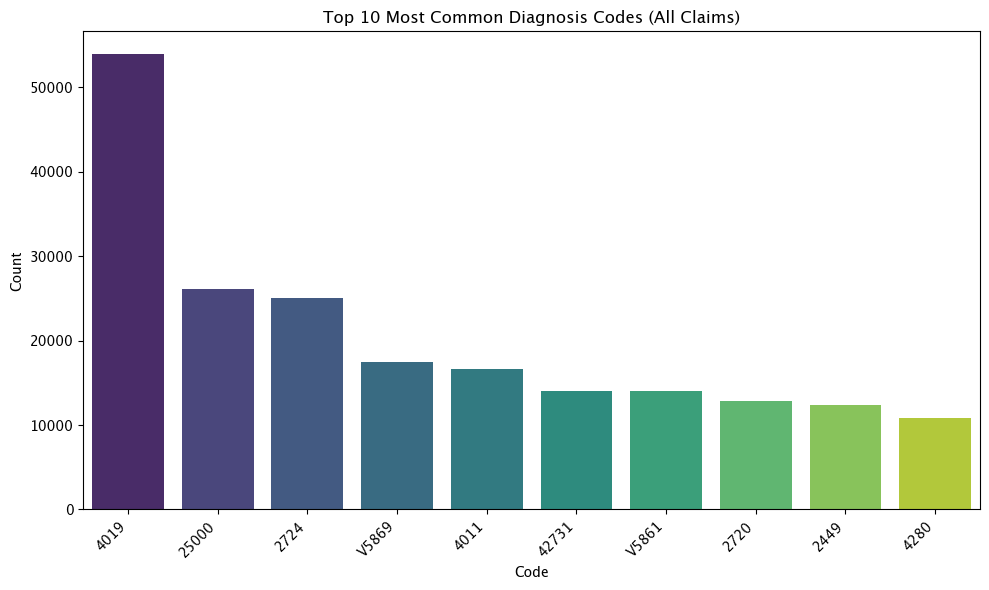

/var/folders/l4/gm3zx2sj1qb4f9vn8xp6kmf80000gn/T/ipykernel_47248/126904680.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_n.index, y=top_n.values, palette="viridis")


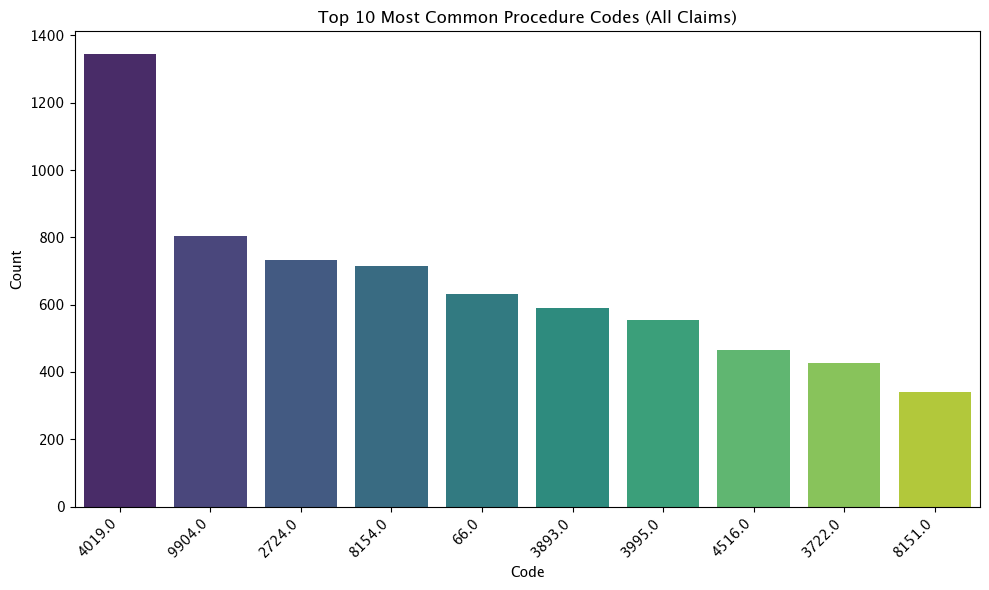


--- Fraud vs. Non-Fraud Comparison Analysis ---


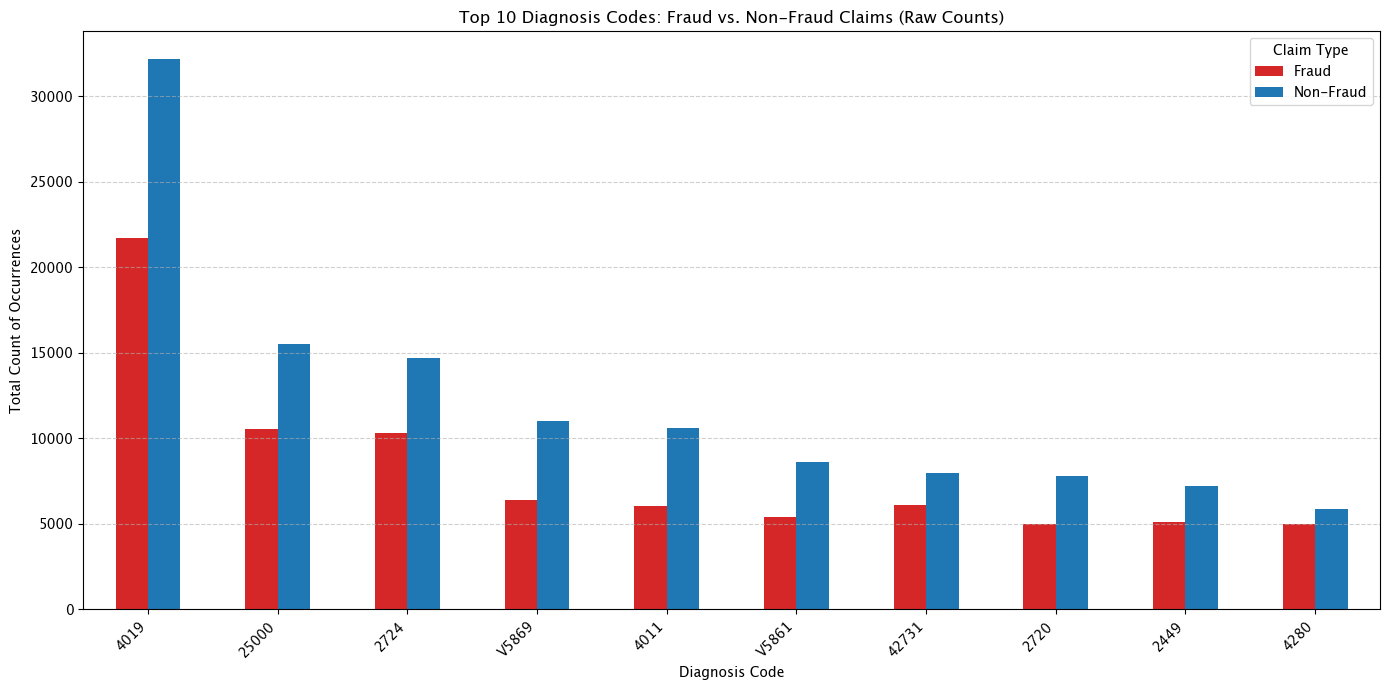

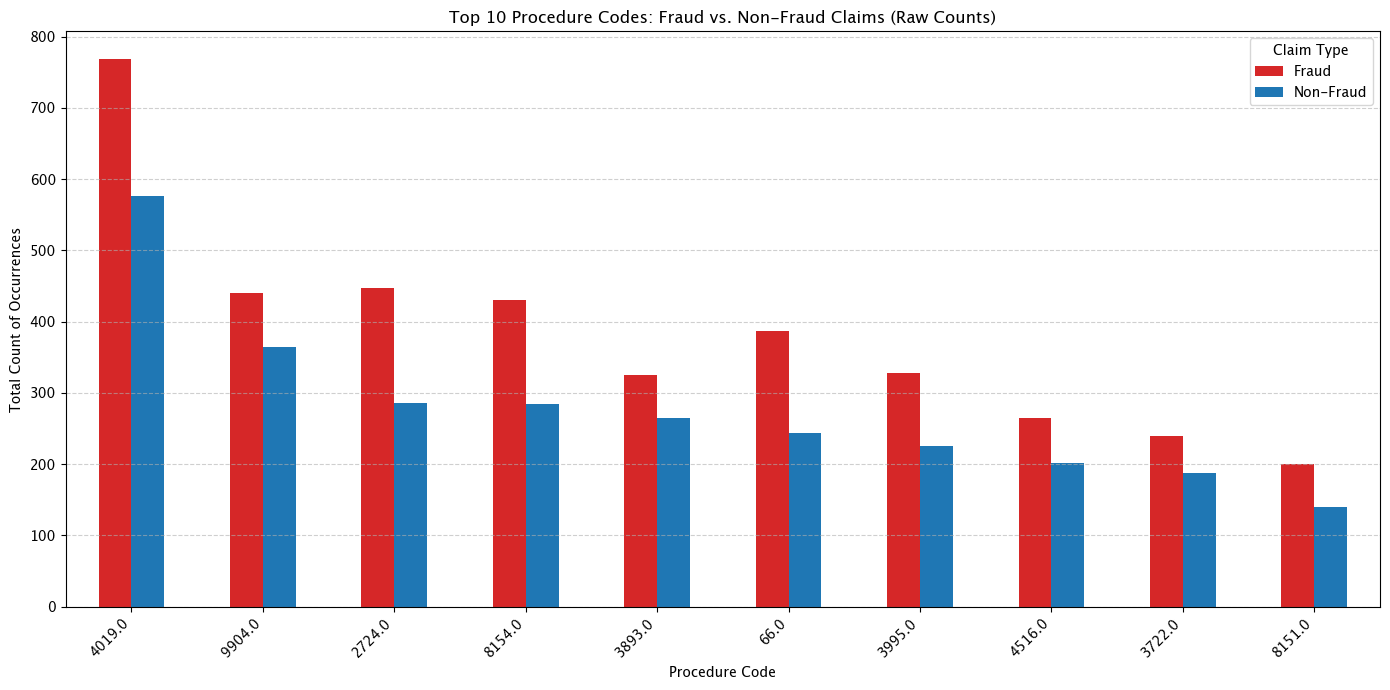

In [21]:
diagnosis_cols = [f'ClmDiagnosisCode_{i}' for i in range(1, 11)]

# Procedure codes run from 1 to 6
procedure_cols = [f'ClmProcedureCode_{i}' for i in range(1, 7)]

def plot_top_n_codes(df, code_cols, title, n=10):
    """Stacks code columns, counts occurrences, and plots the top N."""
    
    # Apply astype(str) to handle mixed types (important for Procedure Codes which are float/int/nan)
    all_codes = df[code_cols].astype(str).stack().value_counts()
    
    # Filter out NaNs if any were converted to 'nan' string
    all_codes = all_codes[all_codes.index != 'nan']
    
    # Select the top N
    top_n = all_codes.head(n)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x=top_n.index, y=top_n.values, palette="viridis")
    plt.title(f'Top {n} Most Common {title}')
    plt.xlabel('Code')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


def get_comparison_counts(df, code_list):
    """Stacks and counts all codes, filtering for a specific list of codes."""
    # Apply astype(str) and stack
    counts = df[code_list].astype(str).stack().value_counts()
    # Filter out NaNs
    counts = counts[counts.index != 'nan']
    return counts


# --- 3. Execution: Individual Plots (Overall Diagnosis and Procedure) ---

print("--- Overall Claim Code Analysis ---")
# 1. ALL Claims Diagnosis
plot_top_n_codes(engineered_train, diagnosis_cols, 'Diagnosis Codes (All Claims)')

# 2. ALL Claims Procedure
plot_top_n_codes(engineered_train, procedure_cols, 'Procedure Codes (All Claims)')


# --- 4. Execution: Fraud vs. Non-Fraud Comparison Plots ---

print("\n--- Fraud vs. Non-Fraud Comparison Analysis ---")

# --- A. Diagnosis Code Comparison ---

# 1. Determine the top 10 most frequent diagnosis codes across ALL claims
all_diag_counts = get_comparison_counts(engineered_train, diagnosis_cols)
top_10_diag_codes = all_diag_counts.head(10).index

# 2. Get counts for the top 10 codes in both groups, re-indexing to ensure common codes
fraud_diag_counts = get_comparison_counts(fraud_train, diagnosis_cols).reindex(top_10_diag_codes, fill_value=0).rename('Fraud')
non_fraud_diag_counts = get_comparison_counts(non_fraud_train, diagnosis_cols).reindex(top_10_diag_codes, fill_value=0).rename('Non-Fraud')

# 3. Combine and sort
diag_plot_df = pd.concat([fraud_diag_counts, non_fraud_diag_counts], axis=1)
diag_plot_df.index.name = 'Diagnosis_Code'
# Sort by Non-Fraud count for typical representation (since Non-Fraud is the largest group)
diag_plot_df = diag_plot_df.sort_values(by='Non-Fraud', ascending=False)

# 4. Plotting Diagnosis results
diag_plot_df.plot(kind='bar', figsize=(14, 7), color=['tab:red', 'tab:blue'])
plt.title('Top 10 Diagnosis Codes: Fraud vs. Non-Fraud Claims (Raw Counts)')
plt.xlabel('Diagnosis Code')
plt.ylabel('Total Count of Occurrences')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Claim Type')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# --- B. Procedure Code Comparison ---

# 1. Determine the top 10 most frequent procedure codes across ALL claims
all_proc_counts = get_comparison_counts(engineered_train, procedure_cols)
top_10_proc_codes = all_proc_counts.head(10).index

# 2. Get counts for the top 10 codes in both groups, re-indexing to ensure common codes
fraud_proc_counts = get_comparison_counts(fraud_train, procedure_cols).reindex(top_10_proc_codes, fill_value=0).rename('Fraud')
non_fraud_proc_counts = get_comparison_counts(non_fraud_train, procedure_cols).reindex(top_10_proc_codes, fill_value=0).rename('Non-Fraud')

# 3. Combine and sort
proc_plot_df = pd.concat([fraud_proc_counts, non_fraud_proc_counts], axis=1)
proc_plot_df.index.name = 'Procedure_Code'
proc_plot_df = proc_plot_df.sort_values(by='Non-Fraud', ascending=False) 

# 4. Plotting Procedure results
proc_plot_df.plot(kind='bar', figsize=(14, 7), color=['tab:red', 'tab:blue'])
plt.title('Top 10 Procedure Codes: Fraud vs. Non-Fraud Claims (Raw Counts)')
plt.xlabel('Procedure Code')
plt.ylabel('Total Count of Occurrences')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Claim Type')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [22]:
# Save engineered datasets (optional - for later use)
print("💾 Saving engineered datasets...")
engineered_train.to_csv("data/engineered_train_split.csv", index=False)
engineered_val.to_csv("data/engineered_val_split.csv", index=False)
engineered_test.to_csv("data/engineered_test.csv", index=False)
print("✅ Saved: engineered_train_split.csv, engineered_val_split.csv, engineered_test.csv")

💾 Saving engineered datasets...
✅ Saved: engineered_train_split.csv, engineered_val_split.csv, engineered_test.csv


## Data Preparation & Scaling (No Leakage)

In [23]:
print("📊 === DATA SCALING (FIT ON TRAIN, TRANSFORM TRAIN & VAL) ===\n")
from sklearn.preprocessing import StandardScaler 

print("🔄 Scaling features using StandardScaler...")
scaler = StandardScaler()

# Prepare training data
X_train = engineered_train.drop(columns=['PotentialFraud']).copy()
y_train = engineered_train['PotentialFraud'].copy()

# Prepare validation data
X_val = engineered_val.drop(columns=['PotentialFraud']).copy()
y_val = engineered_val['PotentialFraud'].copy()

# Prepare test data (no labels)
X_test = engineered_test.copy()

print(f"Training set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set: {X_test.shape}\n")

# Identify columns to exclude from scaling (IDs, categorical codes, dates)
print("🔍 Identifying columns to exclude from scaling...")

# All ID and code columns that should NOT be scaled
exclude_cols = []

# Add all columns that contain IDs or are strings
for col in X_train.columns:
    # Check if column contains string values that can't be converted to numeric
    if X_train[col].dtype == 'object' or pd.api.types.is_string_dtype(X_train[col]):
        exclude_cols.append(col)
    # Also exclude specific ID and code columns by name
    elif any(keyword in col for keyword in ['ClaimID', 'BeneID', 'Provider', 'Physician', 
                                             'ClmDiagnosisCode', 'ClmProcedureCode', 
                                             'DOB', 'DOD', 'Dt', 'Date']):
        exclude_cols.append(col)

exclude_cols = list(set(exclude_cols))  # Remove duplicates
print(f"✅ Excluding {len(exclude_cols)} non-numeric columns from scaling")
print(f"   Examples: {exclude_cols[:5]}...")

# Get only numeric columns for scaling
numeric_cols = [col for col in X_train.columns if col not in exclude_cols]
print(f"✅ Scaling {len(numeric_cols)} numeric columns\n")

# Ensure all numeric columns are actually numeric (convert if possible)
for col in numeric_cols:
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
    X_val[col] = pd.to_numeric(X_val[col], errors='coerce')
    X_test[col] = pd.to_numeric(X_test[col], errors='coerce')

# Simple NaN handling (replace with 0). Change to column means or other imputation if preferred.
X_train[numeric_cols] = X_train[numeric_cols].fillna(0)
X_val[numeric_cols] = X_val[numeric_cols].fillna(0)
X_test[numeric_cols] = X_test[numeric_cols].fillna(0)

# ✅ CRITICAL: Fit scaler ONLY on training data, then transform train, val, and test
print("✅ Fitting scaler on TRAINING data only...")
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
print("✅ Transforming VALIDATION data using training scaler...")
X_val[numeric_cols] = scaler.transform(X_val[numeric_cols])
print("✅ Transforming TEST data using training scaler...")
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

print(f"\n✅ Feature scaling completed (no leakage).\n")

# Drop non-numeric columns (IDs, codes) as they can't be used for modeling
print("🗑️  Dropping non-numeric identifier columns for modeling...")
X_train = X_train[numeric_cols].copy()
X_val = X_val[numeric_cols].copy()
X_test = X_test[numeric_cols].copy()
print(f"✅ Using {len(numeric_cols)} numeric features for modeling\n")

# Reset indices for clean modeling
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
X_val = X_val.reset_index(drop=True)
y_val = y_val.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)

print("📋 Final Dataset Summary:")
print(f"Training set: {X_train.shape[0]:,} samples, {X_train.shape[1]} features")
print(f"Validation set: {X_val.shape[0]:,} samples, {X_val.shape[1]} features")
print(f"Test set: {X_test.shape[0]:,} samples, {X_test.shape[1]} features")

print(f"\n📊 Training set class distribution:")
print(y_train.value_counts())
print(f"Fraud ratio: {y_train.value_counts()[1] / y_train.value_counts()[0]:.3f}")

print(f"\n📊 Validation set class distribution:")
print(y_val.value_counts())
print(f"Fraud ratio: {y_val.value_counts()[1] / y_val.value_counts()[0]:.3f}")

print("\n✅ Data preparation completed successfully (NO DATA LEAKAGE!)")

📊 === DATA SCALING (FIT ON TRAIN, TRANSFORM TRAIN & VAL) ===

🔄 Scaling features using StandardScaler...
Training set: (390747, 75)
Validation set: (167464, 75)
Test set: (135392, 75)

🔍 Identifying columns to exclude from scaling...
✅ Excluding 41 non-numeric columns from scaling
   Examples: ['Provider', 'ClmDiagnosisCode_2', 'ClmProcedureCode_1', 'DischargeDt', 'DOD']...
✅ Scaling 34 numeric columns

✅ Fitting scaler on TRAINING data only...
✅ Transforming VALIDATION data using training scaler...
✅ Transforming TEST data using training scaler...

✅ Feature scaling completed (no leakage).

🗑️  Dropping non-numeric identifier columns for modeling...
✅ Using 34 numeric features for modeling

📋 Final Dataset Summary:
Training set: 390,747 samples, 34 features
Validation set: 167,464 samples, 34 features
Test set: 135,392 samples, 34 features

📊 Training set class distribution:
PotentialFraud
0    241790
1    148957
Name: count, dtype: int64
Fraud ratio: 0.616

📊 Validation set class dis

## Baseline Model Training

In [24]:
print("🚀 === BASELINE MODEL TRAINING WITH CROSS-VALIDATION ===\n")

# Import additional models
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
import warnings
warnings.filterwarnings('ignore')

# Initialize models with default parameters
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1),
    'Naive Bayes': GaussianNB(),
    'KNN': KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'LightGBM': LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1),
    'CatBoost': CatBoostClassifier(random_state=42, verbose=0)
}

# Store results
cv_results = {}
val_results = {}

# Cross-validation setup
cv_folds = 5
skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)

print(f"Training {len(models)} baseline models with {cv_folds}-fold cross-validation...\n")
print("=" * 100)

for model_name, model in models.items():
    print(f"\n📌 Training: {model_name}")
    print("-" * 100)
    
    # Cross-validation on training set (70%)
    print(f"  ⏳ Running {cv_folds}-fold CV on training set...")
    cv_scores = cross_val_score(
        model, X_train, y_train, 
        cv=skf, 
        scoring='roc_auc', 
        n_jobs=-1
    )
    
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()
    cv_results[model_name] = {
        'scores': cv_scores,
        'mean': cv_mean,
        'std': cv_std
    }
    
    print(f"  ✅ CV ROC-AUC: {cv_mean:.4f} (+/- {cv_std:.4f})")
    
    # Train on full training set and evaluate on validation set
    print(f"  ⏳ Training on full 70% and validating on 30%...")
    model.fit(X_train, y_train)
    
    # Predictions on validation set
    y_val_pred = model.predict(X_val)
    y_val_prob = model.predict_proba(X_val)[:, 1]
    
    # Calculate metrics
    val_accuracy = accuracy_score(y_val, y_val_pred)
    val_precision = precision_score(y_val, y_val_pred, zero_division=0)
    val_recall = recall_score(y_val, y_val_pred)
    val_f1 = f1_score(y_val, y_val_pred)
    val_roc_auc = roc_auc_score(y_val, y_val_prob)
    
    val_results[model_name] = {
        'accuracy': val_accuracy,
        'precision': val_precision,
        'recall': val_recall,
        'f1': val_f1,
        'roc_auc': val_roc_auc,
        'predictions': y_val_pred,
        'probabilities': y_val_prob,
        'model': model
    }
    
    print(f"  📊 Validation Results:")
    print(f"     • Accuracy:  {val_accuracy:.4f}")
    print(f"     • Precision: {val_precision:.4f}")
    print(f"     • Recall:    {val_recall:.4f}")
    print(f"     • F1-Score:  {val_f1:.4f}")
    print(f"     • ROC-AUC:   {val_roc_auc:.4f}")

print("\n" + "=" * 100)
print("✅ All baseline models trained successfully!\n")

🚀 === BASELINE MODEL TRAINING WITH CROSS-VALIDATION ===

Training 7 baseline models with 5-fold cross-validation...


📌 Training: Logistic Regression
----------------------------------------------------------------------------------------------------
  ⏳ Running 5-fold CV on training set...
  ✅ CV ROC-AUC: 0.5553 (+/- 0.0023)
  ⏳ Training on full 70% and validating on 30%...
  📊 Validation Results:
     • Accuracy:  0.6296
     • Precision: 0.5746
     • Recall:    0.1095
     • F1-Score:  0.1839
     • ROC-AUC:   0.5552

📌 Training: Random Forest
----------------------------------------------------------------------------------------------------
  ⏳ Running 5-fold CV on training set...
  ✅ CV ROC-AUC: 0.7636 (+/- 0.0022)
  ⏳ Training on full 70% and validating on 30%...
  📊 Validation Results:
     • Accuracy:  0.7232
     • Precision: 0.6572
     • Recall:    0.5725
     • F1-Score:  0.6119
     • ROC-AUC:   0.7708

📌 Training: XGBoost
------------------------------------------------

In [25]:
print("📊 === MODEL PERFORMANCE COMPARISON ===\n")

# Create summary DataFrame
summary_data = []
for model_name in models.keys():
    summary_data.append({
        'Model': model_name,
        'CV ROC-AUC (Mean)': cv_results[model_name]['mean'],
        'CV ROC-AUC (Std)': cv_results[model_name]['std'],
        'Val Accuracy': val_results[model_name]['accuracy'],
        'Val Precision': val_results[model_name]['precision'],
        'Val Recall': val_results[model_name]['recall'],
        'Val F1-Score': val_results[model_name]['f1'],
        'Val ROC-AUC': val_results[model_name]['roc_auc']
    })

results_df = pd.DataFrame(summary_data)
results_df = results_df.sort_values('Val ROC-AUC', ascending=False)

print("Model Performance Summary:")
print(results_df.to_string(index=False))
print("\n")

# Find best model
best_model_name = results_df.iloc[0]['Model']
best_roc_auc = results_df.iloc[0]['Val ROC-AUC']
print(f"🏆 Best Model: {best_model_name} with Validation ROC-AUC = {best_roc_auc:.4f}\n")

📊 === MODEL PERFORMANCE COMPARISON ===

Model Performance Summary:
              Model  CV ROC-AUC (Mean)  CV ROC-AUC (Std)  Val Accuracy  Val Precision  Val Recall  Val F1-Score  Val ROC-AUC
            XGBoost           0.817455          0.002297      0.764355       0.738117    0.591833      0.656930     0.819462
           CatBoost           0.816107          0.002024      0.764600       0.739608    0.590329      0.656591     0.819320
           LightGBM           0.802055          0.002448      0.748322       0.736699    0.528783      0.615661     0.802380
      Random Forest           0.763640          0.002228      0.723194       0.657196    0.572503      0.611933     0.770788
                KNN           0.659449          0.002487      0.657025       0.557462    0.486521      0.519581     0.677533
Logistic Regression           0.555337          0.002334      0.629622       0.574577    0.109463      0.183892     0.555218
        Naive Bayes           0.543226          0.001779  

📈 === VISUALIZING MODEL PERFORMANCE ===



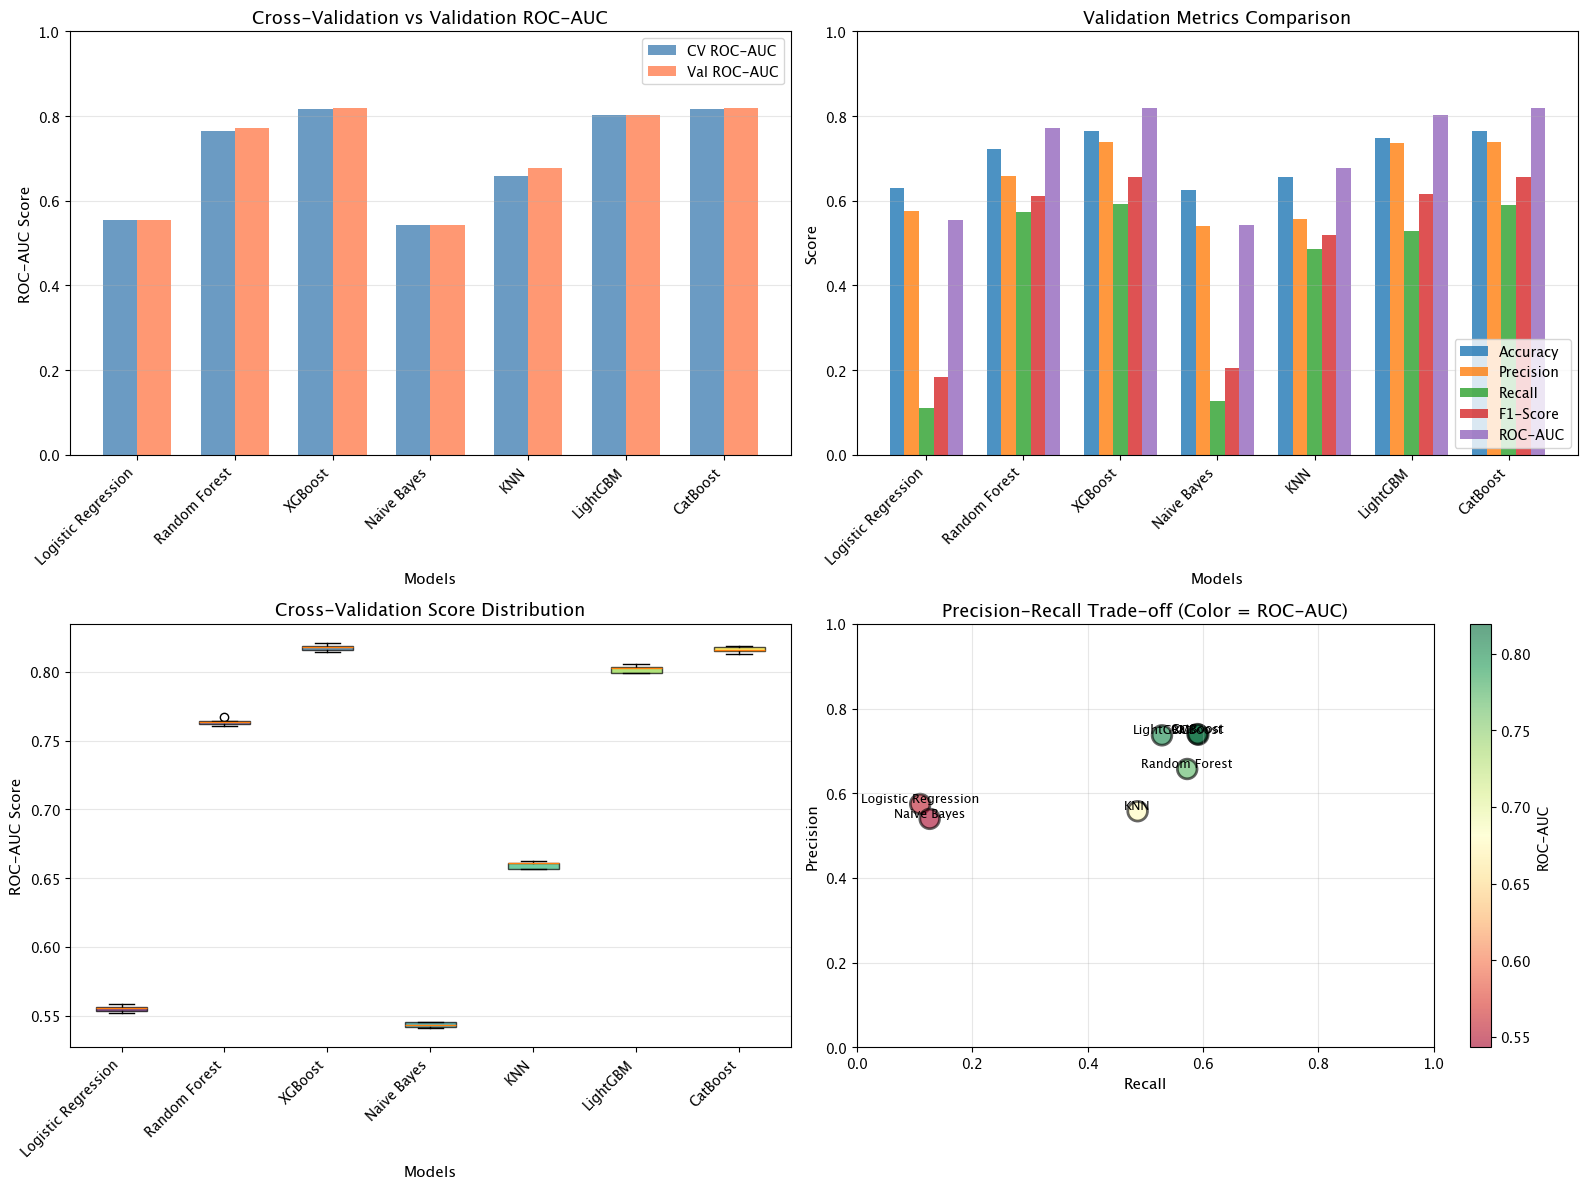

✅ Visualizations generated successfully!


In [26]:
print("📈 === VISUALIZING MODEL PERFORMANCE ===\n")

# Create subplots for comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. ROC-AUC Comparison (CV vs Validation)
ax1 = axes[0, 0]
model_names = list(models.keys())
cv_aucs = [cv_results[m]['mean'] for m in model_names]
val_aucs = [val_results[m]['roc_auc'] for m in model_names]

x = np.arange(len(model_names))
width = 0.35

bars1 = ax1.bar(x - width/2, cv_aucs, width, label='CV ROC-AUC', alpha=0.8, color='steelblue')
bars2 = ax1.bar(x + width/2, val_aucs, width, label='Val ROC-AUC', alpha=0.8, color='coral')

ax1.set_xlabel('Models', fontsize=11, fontweight='bold')
ax1.set_ylabel('ROC-AUC Score', fontsize=11, fontweight='bold')
ax1.set_title('Cross-Validation vs Validation ROC-AUC', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(model_names, rotation=45, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim([0, 1])

# 2. Validation Metrics Comparison
ax2 = axes[0, 1]
metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

# Create a grouped bar chart
x = np.arange(len(model_names))
width = 0.15

for i, metric in enumerate(metrics):
    values = [val_results[m][metric] for m in model_names]
    ax2.bar(x + i*width, values, width, label=metric_labels[i], alpha=0.8)

ax2.set_xlabel('Models', fontsize=11, fontweight='bold')
ax2.set_ylabel('Score', fontsize=11, fontweight='bold')
ax2.set_title('Validation Metrics Comparison', fontsize=13, fontweight='bold')
ax2.set_xticks(x + width * 2)
ax2.set_xticklabels(model_names, rotation=45, ha='right')
ax2.legend(loc='lower right')
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim([0, 1])

# 3. Cross-Validation Score Distribution (Box Plot)
ax3 = axes[1, 0]
cv_data = [cv_results[m]['scores'] for m in model_names]
bp = ax3.boxplot(cv_data, labels=model_names, patch_artist=True)

# Color the boxes
colors = plt.cm.viridis(np.linspace(0, 1, len(model_names)))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax3.set_xlabel('Models', fontsize=11, fontweight='bold')
ax3.set_ylabel('ROC-AUC Score', fontsize=11, fontweight='bold')
ax3.set_title('Cross-Validation Score Distribution', fontsize=13, fontweight='bold')
ax3.set_xticklabels(model_names, rotation=45, ha='right')
ax3.grid(axis='y', alpha=0.3)

# 4. Precision-Recall Trade-off
ax4 = axes[1, 1]
precisions = [val_results[m]['precision'] for m in model_names]
recalls = [val_results[m]['recall'] for m in model_names]

scatter = ax4.scatter(recalls, precisions, s=200, c=val_aucs, cmap='RdYlGn', 
                     alpha=0.6, edgecolors='black', linewidth=2)

# Add model labels
for i, model_name in enumerate(model_names):
    ax4.annotate(model_name, (recalls[i], precisions[i]), 
                fontsize=9, ha='center', va='bottom')

ax4.set_xlabel('Recall', fontsize=11, fontweight='bold')
ax4.set_ylabel('Precision', fontsize=11, fontweight='bold')
ax4.set_title('Precision-Recall Trade-off (Color = ROC-AUC)', fontsize=13, fontweight='bold')
ax4.grid(alpha=0.3)
ax4.set_xlim([0, 1])
ax4.set_ylim([0, 1])

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax4)
cbar.set_label('ROC-AUC', fontsize=10)

plt.tight_layout()
plt.show()

print("✅ Visualizations generated successfully!")

🎯 === ROC CURVES FOR ALL MODELS ===



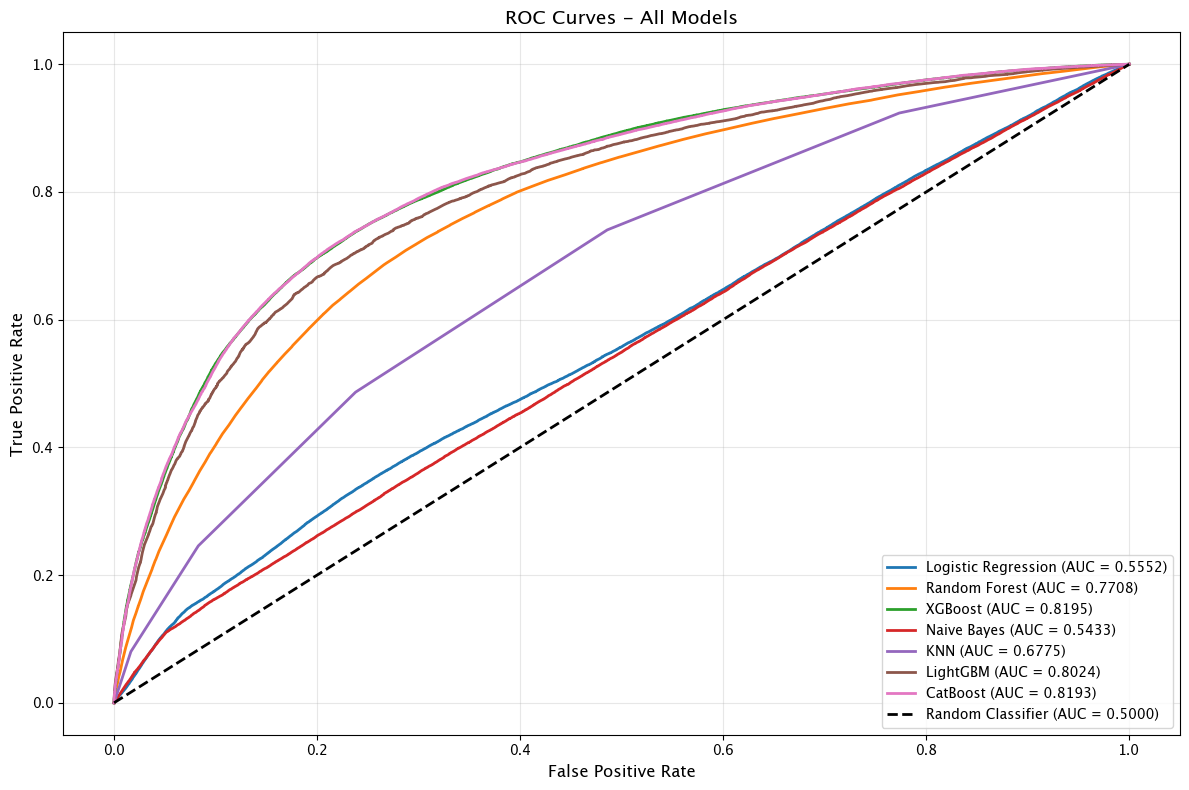

✅ ROC curves plotted successfully!


In [27]:
print("🎯 === ROC CURVES FOR ALL MODELS ===\n")

# Plot ROC curves for all models
plt.figure(figsize=(12, 8))

for model_name in models.keys():
    y_prob = val_results[model_name]['probabilities']
    fpr, tpr, _ = roc_curve(y_val, y_prob)
    auc_score = val_results[model_name]['roc_auc']
    
    plt.plot(fpr, tpr, linewidth=2, label=f'{model_name} (AUC = {auc_score:.4f})')

# Plot diagonal line (random classifier)
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier (AUC = 0.5000)')

plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('ROC Curves - All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("✅ ROC curves plotted successfully!")

🔍 === CONFUSION MATRICES (All Models) ===



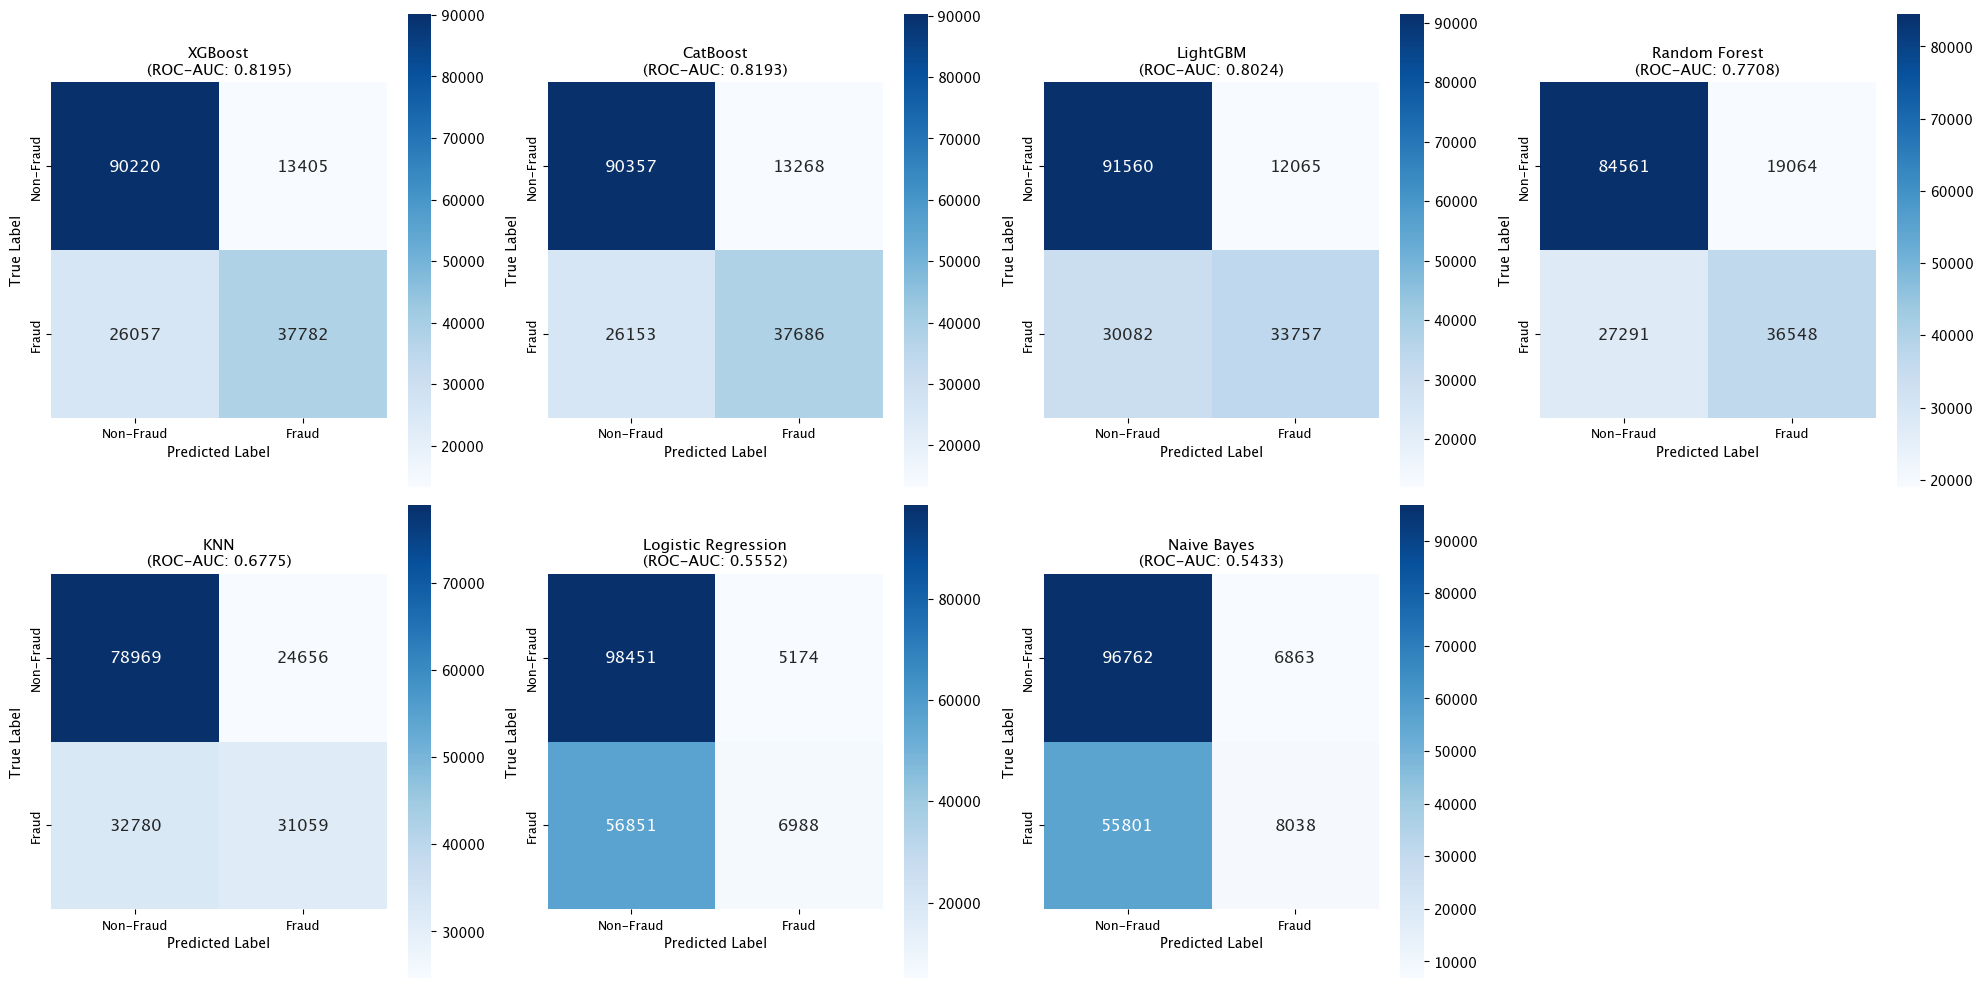

✅ Confusion matrices displayed for all 7 models!


In [28]:
print("🔍 === CONFUSION MATRICES (All Models) ===\n")

# Get all models sorted by validation ROC-AUC
all_models = results_df['Model'].tolist()
n_models = len(all_models)

# Create subplots with 2 rows and 4 columns to fit all 7 models
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()  # Flatten to make indexing easier

for idx, model_name in enumerate(all_models):
    y_pred = val_results[model_name]['predictions']
    cm = confusion_matrix(y_val, y_pred)
    
    # Plot confusion matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                ax=axes[idx], cbar=True, square=True,
                annot_kws={'size': 12, 'weight': 'bold'})
    
    axes[idx].set_title(f'{model_name}\n(ROC-AUC: {val_results[model_name]["roc_auc"]:.4f})', 
                       fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('True Label', fontsize=10, fontweight='bold')
    axes[idx].set_xlabel('Predicted Label', fontsize=10, fontweight='bold')
    axes[idx].set_xticklabels(['Non-Fraud', 'Fraud'], fontsize=9)
    axes[idx].set_yticklabels(['Non-Fraud', 'Fraud'], fontsize=9)

# Hide the last empty subplot (8th position)
axes[-1].axis('off')

plt.tight_layout()
plt.show()

print(f"✅ Confusion matrices displayed for all {n_models} models!")

In [30]:
print("💾 === SAVING RESULTS AND MODELS ===\n")


# Create a detailed results summary
detailed_summary = []
for model_name in models.keys():
    detailed_summary.append({
        'Model': model_name,
        'CV_Mean': cv_results[model_name]['mean'],
        'CV_Std': cv_results[model_name]['std'],
        'CV_Fold_1': cv_results[model_name]['scores'][0],
        'CV_Fold_2': cv_results[model_name]['scores'][1],
        'CV_Fold_3': cv_results[model_name]['scores'][2],
        'CV_Fold_4': cv_results[model_name]['scores'][3],
        'CV_Fold_5': cv_results[model_name]['scores'][4],
        'Val_Accuracy': val_results[model_name]['accuracy'],
        'Val_Precision': val_results[model_name]['precision'],
        'Val_Recall': val_results[model_name]['recall'],
        'Val_F1': val_results[model_name]['f1'],
        'Val_ROC_AUC': val_results[model_name]['roc_auc']
    })

detailed_df = pd.DataFrame(detailed_summary)
detailed_df.to_csv("results/detailed_baseline_results.csv", index=False)
print("✅ Detailed results saved to: results/detailed_baseline_results.csv")

print(f"\n{'='*80}")
print("🎉 BASELINE MODEL TRAINING COMPLETE!")
print(f"{'='*80}")
print(f"\n📊 Summary:")
print(f"   • Total models trained: {len(models)}")
print(f"   • Best performing model: {best_model_name}")
print(f"   • Best validation ROC-AUC: {best_roc_auc:.4f}")
print(f"   • Best validation F1-Score: {val_results[best_model_name]['f1']:.4f}")
print(f"\n🛡️  Data Leakage Prevention:")
print(f"   ✅ Training set: {X_train.shape[0]:,} samples (70%)")
print(f"   ✅ Validation set: {X_val.shape[0]:,} samples (30%)")
print(f"   ✅ Features engineered on training split only")
print(f"   ✅ Scaler fit on training split only")
print(f"   ✅ Physician stats from training split only")
print(f"   ✅ Validation metrics are UNBIASED and RELIABLE")
print(f"\n💡 Next Steps:")
print("   1. Perform hyperparameter tuning on top models")
print("   2. Feature importance analysis")
print("   3. Handle class imbalance (SMOTE, class weights)")
print("   4. Ensemble methods")

💾 === SAVING RESULTS AND MODELS ===

✅ Detailed results saved to: results/detailed_baseline_results.csv

🎉 BASELINE MODEL TRAINING COMPLETE!

📊 Summary:
   • Total models trained: 7
   • Best performing model: XGBoost
   • Best validation ROC-AUC: 0.8195
   • Best validation F1-Score: 0.6569

🛡️  Data Leakage Prevention:
   ✅ Training set: 390,747 samples (70%)
   ✅ Validation set: 167,464 samples (30%)
   ✅ Features engineered on training split only
   ✅ Scaler fit on training split only
   ✅ Physician stats from training split only
   ✅ Validation metrics are UNBIASED and RELIABLE

💡 Next Steps:
   1. Perform hyperparameter tuning on top models
   2. Feature importance analysis
   3. Handle class imbalance (SMOTE, class weights)
   4. Ensemble methods
